## Feature Selection

Importancia agrupada por característica original (permutation mean CV):


,feature,perm_mean_cv,perm_std_cv
0,1t glucosa,0.050877,0.025057
1,1T hemoglobina glicada,0.036565,0.019393
2,bmi,0.011007,0.031767
3,edad,0.007207,0.027111
4,diabetes franca 1T,0.000000,0.000000
5,factores riesgo,-0.002356,0.081700
6,etnia,-0.020754,0.059119


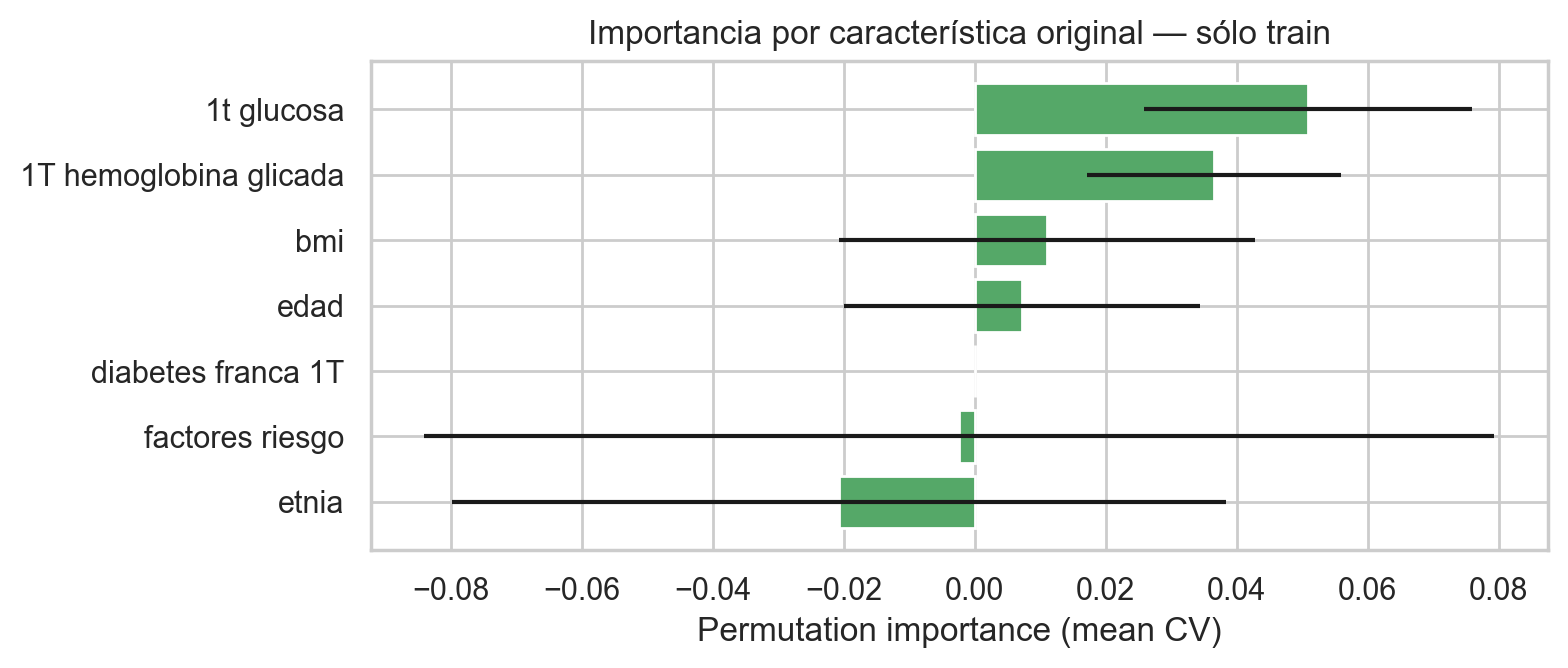

In [169]:
# Importancia por característica original (permutation importance + CV, solo train)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Umbrales usados (ajusta si tienes variables refined_* en el notebook)
try:
    thresholds = {'bmi': refined_bmi, 'edad': refined_edad,
                  '1T hemoglobina glicada': refined_hba1c, '1t glucosa': refined_gluc}
except NameError:
    thresholds = {'bmi': 30.2, 'edad': 25.0, '1T hemoglobina glicada': 5.4, '1t glucosa': 81.0}

# 1) Pipeline que aplica cortes y preprocesado (ajústalo si quieres escalar distinto)
pipe_tf = Pipeline([
    ('binar', MultiThresholdBinarizer(cuts_map=thresholds)),
    ('preproc', preprocesador_base_dinamico(escalar_numericas=True))
])
pipe_tf.fit(X_train)

# Extraer nombres de características resultantes (método robusto)
def feature_names_from_preprocessor(pre, X):
    names = []
    for name, trans, cols in pre.transformers_:
        if name == 'remainder' and trans == 'drop':
            continue
        # obtener lista de columnas afectadas
        cols_list = list(cols) if hasattr(cols, '__iter__') and not isinstance(cols, str) else [cols]
        if hasattr(trans, 'named_steps') and 'onehot' in trans.named_steps:
            ohe = trans.named_steps['onehot']
            try:
                ohe_names = ohe.get_feature_names_out(cols_list)
            except Exception:
                ohe_names = ohe.get_feature_names(cols_list)
            names.extend(list(ohe_names))
        else:
            names.extend(cols_list)
    return names

pre = pipe_tf.named_steps['preproc']
feat_names = feature_names_from_preprocessor(pre, X_train)

# 2) Obtener transformados por fold y calcular permutation importance en CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
perm_fold_scores = []  # filas: folds, columnas: features (en el mismo orden que feat_names)

for train_idx, val_idx in cv.split(X_train, y_train):
    Xtr = X_train.iloc[train_idx]
    ytr = y_train.iloc[train_idx]
    Xval = X_train.iloc[val_idx]
    yval = y_train.iloc[val_idx]

    # re-ajustar transformador en fold train
    fold_pipe = Pipeline([
        ('binar', MultiThresholdBinarizer(cuts_map=thresholds)),
        ('preproc', preprocesador_base_dinamico(escalar_numericas=True))
    ])
    fold_pipe.fit(Xtr)
    Xtr_t = fold_pipe.transform(Xtr)
    Xval_t = fold_pipe.transform(Xval)

    # entrenar RF y calcular importance por permutación en val
    rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
    rf.fit(Xtr_t, ytr)
    perm = permutation_importance(rf, Xval_t, yval, n_repeats=30, scoring='roc_auc', random_state=0, n_jobs=-1)
    perm_fold_scores.append(perm.importances_mean)

perm_scores = np.vstack(perm_fold_scores)  # shape (n_folds, n_features)
perm_mean = perm_scores.mean(axis=0)
perm_std = perm_scores.std(axis=0)

# 3) Mapear cada feat_name a la columna original que la generó
# Tomamos las columnas originales usadas por el preprocesador
orig_cols = []
for name, trans, cols in pre.transformers_:
    if name == 'remainder' and trans == 'drop':
        continue
    cols_list = list(cols) if hasattr(cols, '__iter__') and not isinstance(cols, str) else [cols]
    orig_cols.extend(cols_list)
orig_cols = list(dict.fromkeys(orig_cols))  # mantener orden único

# función que asigna un nombre de output a su columna origen
def map_to_orig(feat_name, orig_cols):
    for orig in orig_cols:
        # varios patrones comunes de get_feature_names_out: "col_val", "col=val", "col__val"
        if feat_name == orig:
            return orig
        if feat_name.startswith(f"{orig}_") or feat_name.startswith(f"{orig}=") or feat_name.startswith(f"{orig}__") or feat_name.startswith(f"{orig}-"):
            return orig
    # fallback: buscar si orig aparece como substring
    for orig in orig_cols:
        if orig in feat_name:
            return orig
    return 'other'

mapping = [map_to_orig(fn, orig_cols) for fn in feat_names]

# 4) Agrupar importancias por columna original (sumando las importancias de sus columnas derivadas)
group_names = sorted(set(mapping))
group_scores = {}
for g in group_names:
    cols_idx = [i for i, m in enumerate(mapping) if m == g]
    # sumar por fold para obtener distribución por fold y luego estadísticos
    if len(cols_idx) == 0:
        continue
    group_fold = perm_scores[:, cols_idx].sum(axis=1)  # suma por fold
    group_scores[g] = {
        'mean': float(group_fold.mean()),
        'std': float(group_fold.std(ddof=1))
    }

# 5) Resultado en DataFrame ordenado
df_group = pd.DataFrame([
    {'feature': k, 'perm_mean_cv': v['mean'], 'perm_std_cv': v['std']} for k, v in group_scores.items()
]).sort_values('perm_mean_cv', ascending=False).reset_index(drop=True)

print("Importancia agrupada por característica original (permutation mean CV):")
display(df_group)

# 6) Plot
plt.figure(figsize=(8, max(3, 0.5*len(df_group))))
plt.barh(df_group['feature'], df_group['perm_mean_cv'], xerr=df_group['perm_std_cv'], color='C2')
plt.gca().invert_yaxis()
plt.xlabel('Permutation importance (mean CV)')
plt.title('Importancia por característica original — sólo train')
plt.tight_layout()
plt.show()

Top-4 features por importancia: ['1t glucosa', '1T hemoglobina glicada', 'bmi', 'edad']


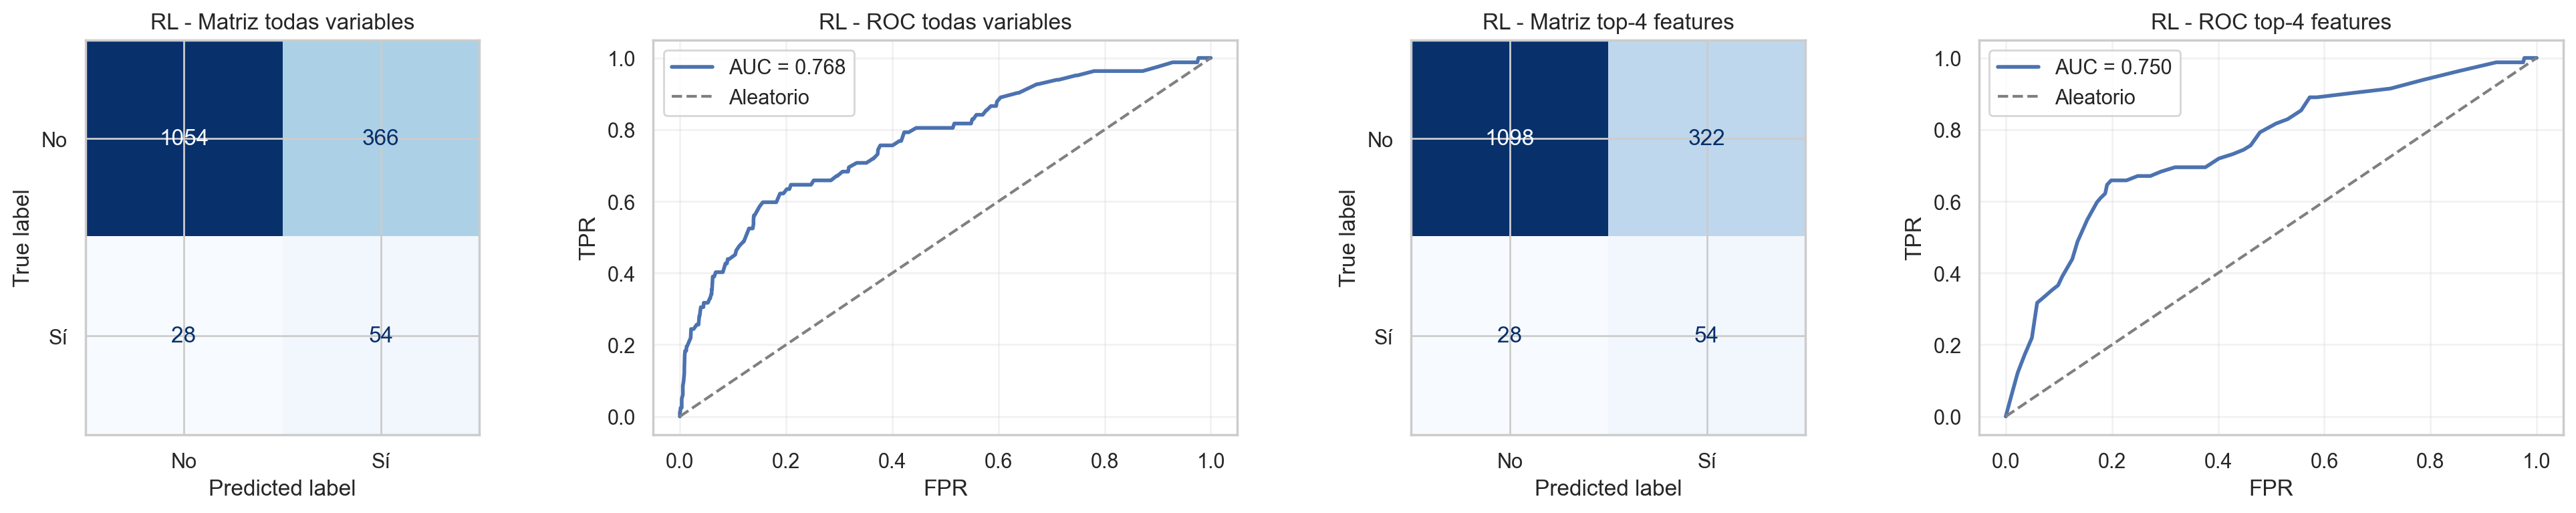


MÉTRICAS - REGRESIÓN LOGÍSTICA (RL)

CORTES ÓPTIMOS - TODAS LAS VARIABLES:
  ROC-AUC: 0.7670
  PR-AUC:  0.2700
  F1:      0.2080

CORTES ÓPTIMOS - TOP-4 FEATURES: ['1t glucosa', '1T hemoglobina glicada', 'bmi', 'edad']
  ROC-AUC: 0.7574
  PR-AUC:  0.1660
  F1:      0.2295


In [170]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Cortes óptimos

refined_bmi = 30.2
refined_edad = 25.0
refined_hba1c = 5.4
refined_gluc = 81.0

cuts_optimos = {
    "bmi": refined_bmi,
    "edad": refined_edad,
    "1T hemoglobina glicada": refined_hba1c,
    "1t glucosa": refined_gluc
}

# Obtener top-4 features de importancia
top_4_features = df_group['feature'].values[:4].tolist()
print(f"Top-4 features por importancia: {top_4_features}")

# Asegura que existe el builder de RL
if "build_pipeline_lr" not in globals():
    raise NameError("Falta ejecutar antes la celda que define build_pipeline_lr")

class MultiThresholdBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, cuts_map=None):
        self.cuts_map = cuts_map or {}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X2 = X.copy()
        for col, thr in self.cuts_map.items():
            if col in X2.columns and thr is not None:
                vals = pd.to_numeric(X2[col], errors="coerce")
                X2[col] = (vals >= float(thr)).astype(int).fillna(0)
        return X2

def construir_pipe_fair(cuts_map, builder_func, X_df):
    return Pipeline([
        ("binar", MultiThresholdBinarizer(cuts_map=cuts_map)),
        ("model", builder_func(X_df))
    ])

# Solo RL
builder_func = build_pipeline_lr
nombre = "RL"

# Validación para tabla final
cv_table = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=123)
scoring_table = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

# Validación para figura
cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Preparar datos para top-4 features
X_top4 = X_train[top_4_features].copy()
cuts_optimos_top4 = {k: v for k, v in cuts_optimos.items() if k in top_4_features}

# Pipelines
pipe_optimo_all = construir_pipe_fair(cuts_optimos, builder_func, X_train)
pipe_optimo_top4 = construir_pipe_fair(cuts_optimos_top4, builder_func, X_top4)

# Evaluación
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    scores_opt_all = cross_validate(
        pipe_optimo_all,
        X_train,
        y_train,
        cv=cv_table,
        scoring=scoring_table,
        n_jobs=-1
    )
    scores_opt_top4 = cross_validate(
        pipe_optimo_top4,
        X_top4,
        y_train,
        cv=cv_table,
        scoring=scoring_table,
        n_jobs=-1
    )

resultados_opt_all = {
    "roc_auc": float(np.mean(scores_opt_all["test_roc_auc"])),
    "pr_auc": float(np.mean(scores_opt_all["test_pr_auc"])),
    "f1": float(np.mean(scores_opt_all["test_f1"]))
}

resultados_opt_top4 = {
    "roc_auc": float(np.mean(scores_opt_top4["test_roc_auc"])),
    "pr_auc": float(np.mean(scores_opt_top4["test_pr_auc"])),
    "f1": float(np.mean(scores_opt_top4["test_f1"]))
}

# Predicciones para la figura
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    y_pred_all = cross_val_predict(pipe_optimo_all, X_train, y_train, cv=cv_plot)
    y_proba_all = cross_val_predict(pipe_optimo_all, X_train, y_train, cv=cv_plot, method="predict_proba")[:, 1]
    y_pred_top4 = cross_val_predict(pipe_optimo_top4, X_top4, y_train, cv=cv_plot)
    y_proba_top4 = cross_val_predict(pipe_optimo_top4, X_top4, y_train, cv=cv_plot, method="predict_proba")[:, 1]

auc_all = roc_auc_score(y_train, y_proba_all)
auc_top4 = roc_auc_score(y_train, y_proba_top4)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Matriz: cortes óptimos todas las variables
cm_all = confusion_matrix(y_train, y_pred_all)
disp_all = ConfusionMatrixDisplay(confusion_matrix=cm_all, display_labels=["No", "Sí"])
disp_all.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("RL - Matriz todas variables")

# ROC: cortes óptimos todas las variables
fpr_all, tpr_all, _ = roc_curve(y_train, y_proba_all)
axes[1].plot(fpr_all, tpr_all, label=f"AUC = {auc_all:.3f}", linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("RL - ROC todas variables")
axes[1].legend()
axes[1].grid(alpha=0.25)

# Matriz: cortes óptimos top-4 features
cm_top4 = confusion_matrix(y_train, y_pred_top4)
disp_top4 = ConfusionMatrixDisplay(confusion_matrix=cm_top4, display_labels=["No", "Sí"])
disp_top4.plot(ax=axes[2], cmap="Blues", colorbar=False, values_format="d")
axes[2].set_title("RL - Matriz top-4 features")

# ROC: cortes óptimos top-4 features
fpr_top4, tpr_top4, _ = roc_curve(y_train, y_proba_top4)
axes[3].plot(fpr_top4, tpr_top4, label=f"AUC = {auc_top4:.3f}", linewidth=2)
axes[3].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatorio")
axes[3].set_xlabel("FPR")
axes[3].set_ylabel("TPR")
axes[3].set_title("RL - ROC top-4 features")
axes[3].legend()
axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Print de métricas
print("\n" + "="*60)
print("MÉTRICAS - REGRESIÓN LOGÍSTICA (RL)")
print("="*60)
print(f"\nCORTES ÓPTIMOS - TODAS LAS VARIABLES:")
print(f"  ROC-AUC: {resultados_opt_all['roc_auc']:.4f}")
print(f"  PR-AUC:  {resultados_opt_all['pr_auc']:.4f}")
print(f"  F1:      {resultados_opt_all['f1']:.4f}")
print(f"\nCORTES ÓPTIMOS - TOP-4 FEATURES: {top_4_features}")
print(f"  ROC-AUC: {resultados_opt_top4['roc_auc']:.4f}")
print(f"  PR-AUC:  {resultados_opt_top4['pr_auc']:.4f}")
print(f"  F1:      {resultados_opt_top4['f1']:.4f}")
print("="*60)

## GridSearch de hiperparámetros

In [171]:
# 1) Preparar datos y cortes para TODAS las variables
X_all = X_train.copy()
cuts_all = cuts_optimos.copy()  # se aplican solo a las columnas presentes en este dict

# 2) Pipeline centrado en RL con binarizador
pipe_rl_grid = Pipeline([
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_all)),
    ("clf", LogisticRegression(max_iter=5000))
])

# 3) Espacio de búsqueda para Regresión Logística
param_grid_rl = [
    # Solvers que soportan L1 y L2 (liblinear y saga)
    {
        "clf__solver": ["liblinear", "saga"],
        "clf__penalty": ["l1", "l2"],
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__class_weight": ["balanced"]
    },
    # Solvers que solo soportan L2 (lbfgs, newton-cg, sag)
    {
        "clf__solver": ["lbfgs", "newton-cg", "sag"],
        "clf__penalty": ["l2"],
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__class_weight": ["balanced"]
    },
    # Solver SAGA para ELASTICNET (combinación L1/L2)
    {
        "clf__solver": ["saga"],
        "clf__penalty": ["elasticnet"],
        "clf__l1_ratio": [0.2, 0.5, 0.8], # Proporción de L1 vs L2
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__class_weight": ["balanced"]
    }
]

# 4) GridSearchCV con ROC-AUC como objetivo
cv_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rl = GridSearchCV(
    pipe_rl_grid,
    param_grid_rl,
    cv=cv_grid,
    scoring={
        "roc_auc": "roc_auc",
        "f1": "f1",
        "average_precision": "average_precision"
    },
    refit="roc_auc",  # refit con el mejor ROC-AUC (puedes cambiar a "roc_auc" si prefieres)
    n_jobs=-1,
    verbose=1
)

# 5) Ejecutar búsqueda
print(f"Ejecutando búsqueda exhaustiva de RL sobre {len(X_all)} muestras y {X_all.shape[1]} variables...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_search_rl.fit(X_all, y_train)

# 6) Reporte
print("\n" + "=" * 60)
print("MEJOR REGRESIÓN LOGÍSTICA (TODAS LAS VARIABLES) MÁXIMO ROC-AUC")
print("=" * 60)
print(f"Mejor ROC-AUC:   {grid_search_rl.best_score_:.4f}")

idx = grid_search_rl.best_index_
print(f"F1 Asociado:     {grid_search_rl.cv_results_['mean_test_f1'][idx]:.4f}")
print(f"PR-AUC Asociado: {grid_search_rl.cv_results_['mean_test_average_precision'][idx]:.4f}")

print("\nConfiguración ganadora:")
for p, val in grid_search_rl.best_params_.items():
    print(f"  - {p.replace('clf__', '')}: {val}")
print("=" * 60)

# Top 10 configuraciones por ROC-AUC
df_rl_results = pd.DataFrame(grid_search_rl.cv_results_)
cols_show = [
    "param_clf__solver", "param_clf__penalty", "param_clf__C",
    "mean_test_roc_auc", "mean_test_f1", "mean_test_average_precision"
]
display(df_rl_results[cols_show].sort_values("mean_test_roc_auc", ascending=False).head(10))


Ejecutando búsqueda exhaustiva de RL sobre 1502 muestras y 7 variables...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

MEJOR REGRESIÓN LOGÍSTICA (TODAS LAS VARIABLES) MÁXIMO ROC-AUC
Mejor ROC-AUC:   0.7724
F1 Asociado:     0.2176
PR-AUC Asociado: 0.2688

Configuración ganadora:
  - C: 0.1
  - class_weight: balanced
  - l1_ratio: 0.5
  - penalty: elasticnet
  - solver: saga


,param_clf__solver,param_clf__penalty,param_clf__C,mean_test_roc_auc,mean_test_f1,mean_test_average_precision
39,saga,elasticnet,0.1,0.772377,0.217577,0.268820
25,sag,l2,0.1,0.772227,0.209965,0.278621
24,newton-cg,l2,0.1,0.772227,0.209965,0.278621
7,saga,l2,0.1,0.772227,0.209965,0.278621
38,saga,elasticnet,0.1,0.772025,0.213663,0.269497
23,lbfgs,l2,0.1,0.771647,0.209965,0.269490
29,lbfgs,l2,10.0,0.770296,0.214510,0.258867
42,saga,elasticnet,1.0,0.770151,0.213712,0.259244
41,saga,elasticnet,1.0,0.770024,0.214143,0.259225
11,saga,l2,1.0,0.770024,0.214143,0.259225


## Test

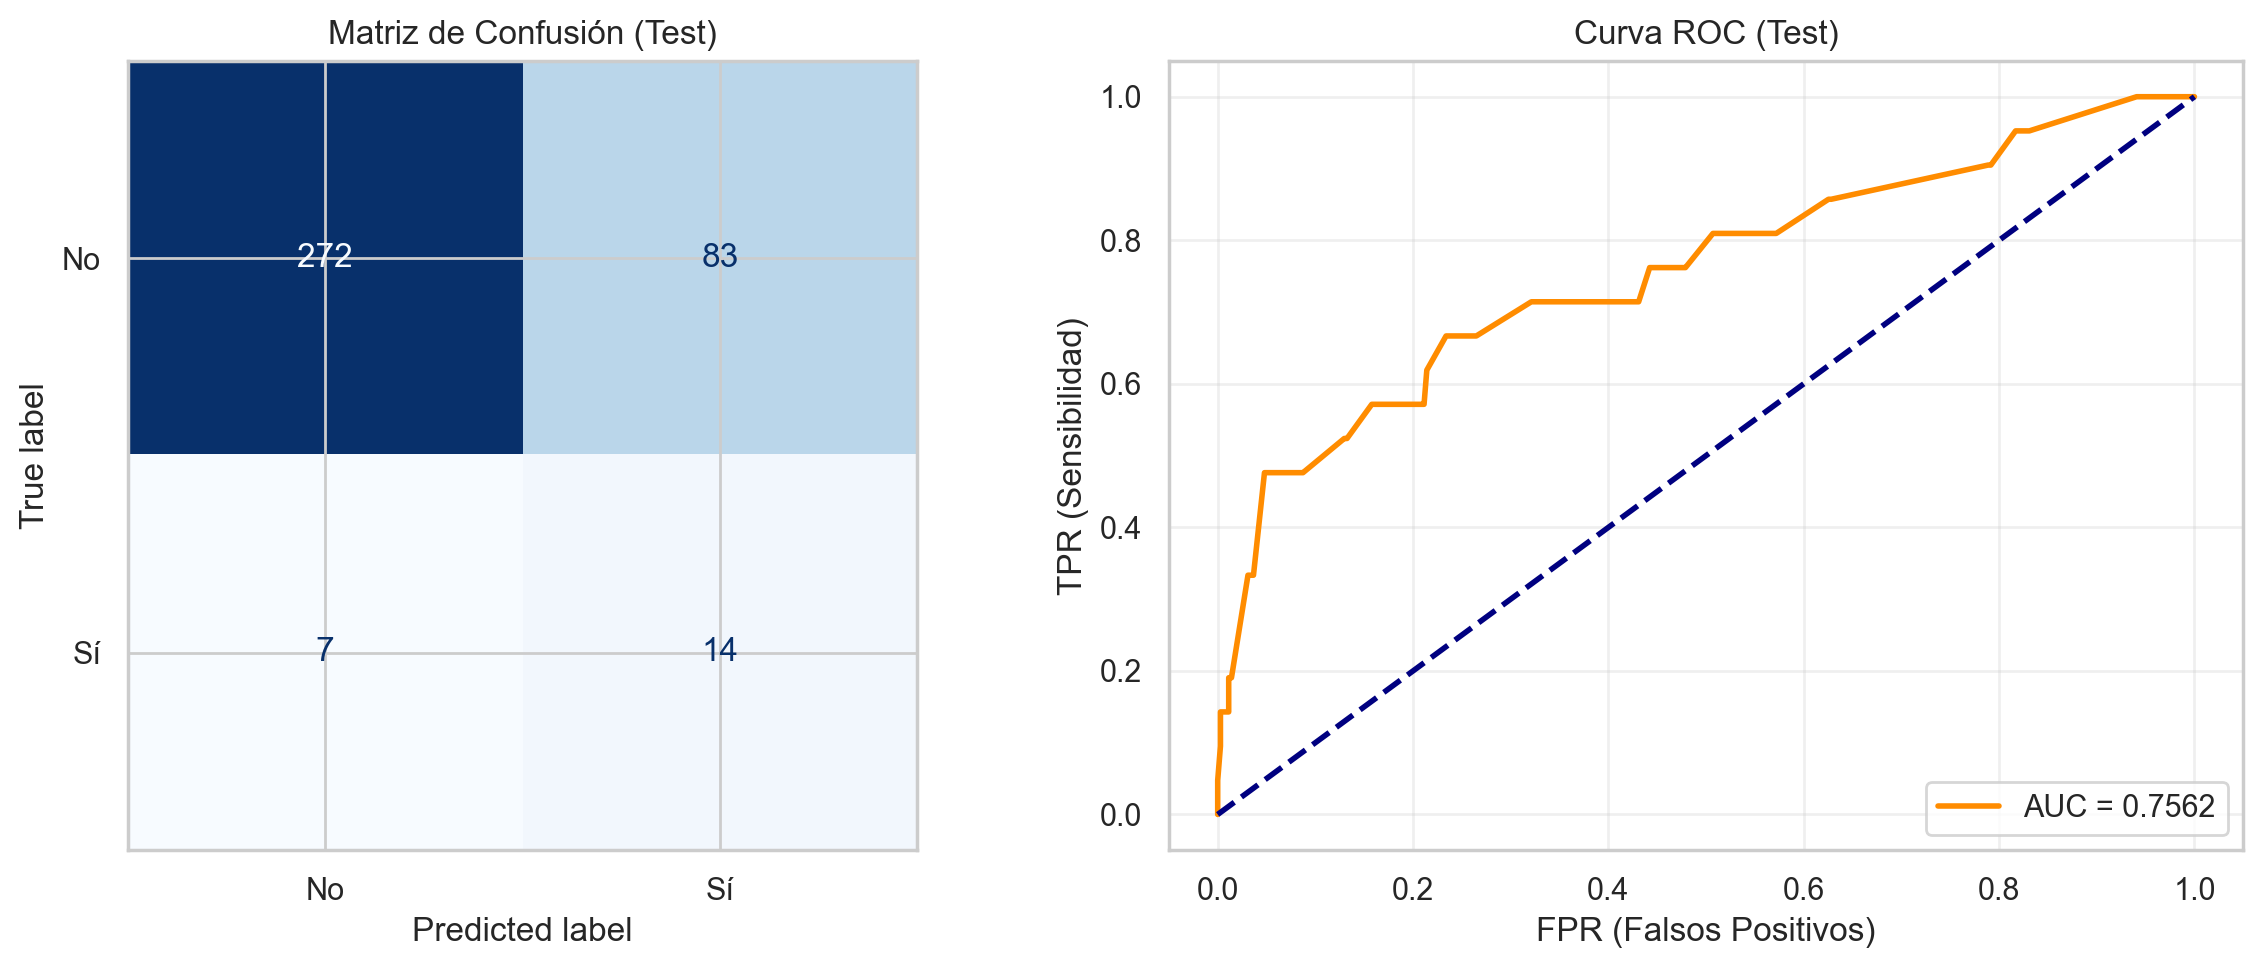


RESULTADOS FINALES SOBRE EL CONJUNTO DE TEST
Mejor configuración utilizada: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.5, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}
------------------------------------------------------------
ROC-AUC:  0.7562
PR-AUC:   0.3053
F1-Score: 0.2373


In [172]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt

# 1. Preparar datos de test
X_test_eval = X_test.copy()

# 2. Usar la mejor configuración obtenida en la celda anterior
best_model = grid_search_rl.best_estimator_

y_pred_test = best_model.predict(X_test_eval)
y_proba_test = best_model.predict_proba(X_test_eval)[:, 1]

# 3. Métricas
auc_test = roc_auc_score(y_test, y_proba_test)
pr_auc_test = average_precision_score(y_test, y_proba_test)
f1_test = f1_score(y_test, y_pred_test)

# 4. Representación visual
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["No", "Sí"])
disp_test.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de Confusión (Test)")

fpr_t, tpr_t, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr_t, tpr_t, label=f"AUC = {auc_test:.4f}", color="darkorange", lw=2)
axes[1].plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
axes[1].set_xlabel("FPR (Falsos Positivos)")
axes[1].set_ylabel("TPR (Sensibilidad)")
axes[1].set_title("Curva ROC (Test)")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Reporte final
print("\n" + "=" * 60)
print("RESULTADOS FINALES SOBRE EL CONJUNTO DE TEST")
print("=" * 60)
print(f"Mejor configuración utilizada: {grid_search_rl.best_params_}")
print("-" * 60)
print(f"ROC-AUC:  {auc_test:.4f}")
print(f"PR-AUC:   {pr_auc_test:.4f}")
print(f"F1-Score: {f1_test:.4f}")
print("=" * 60)


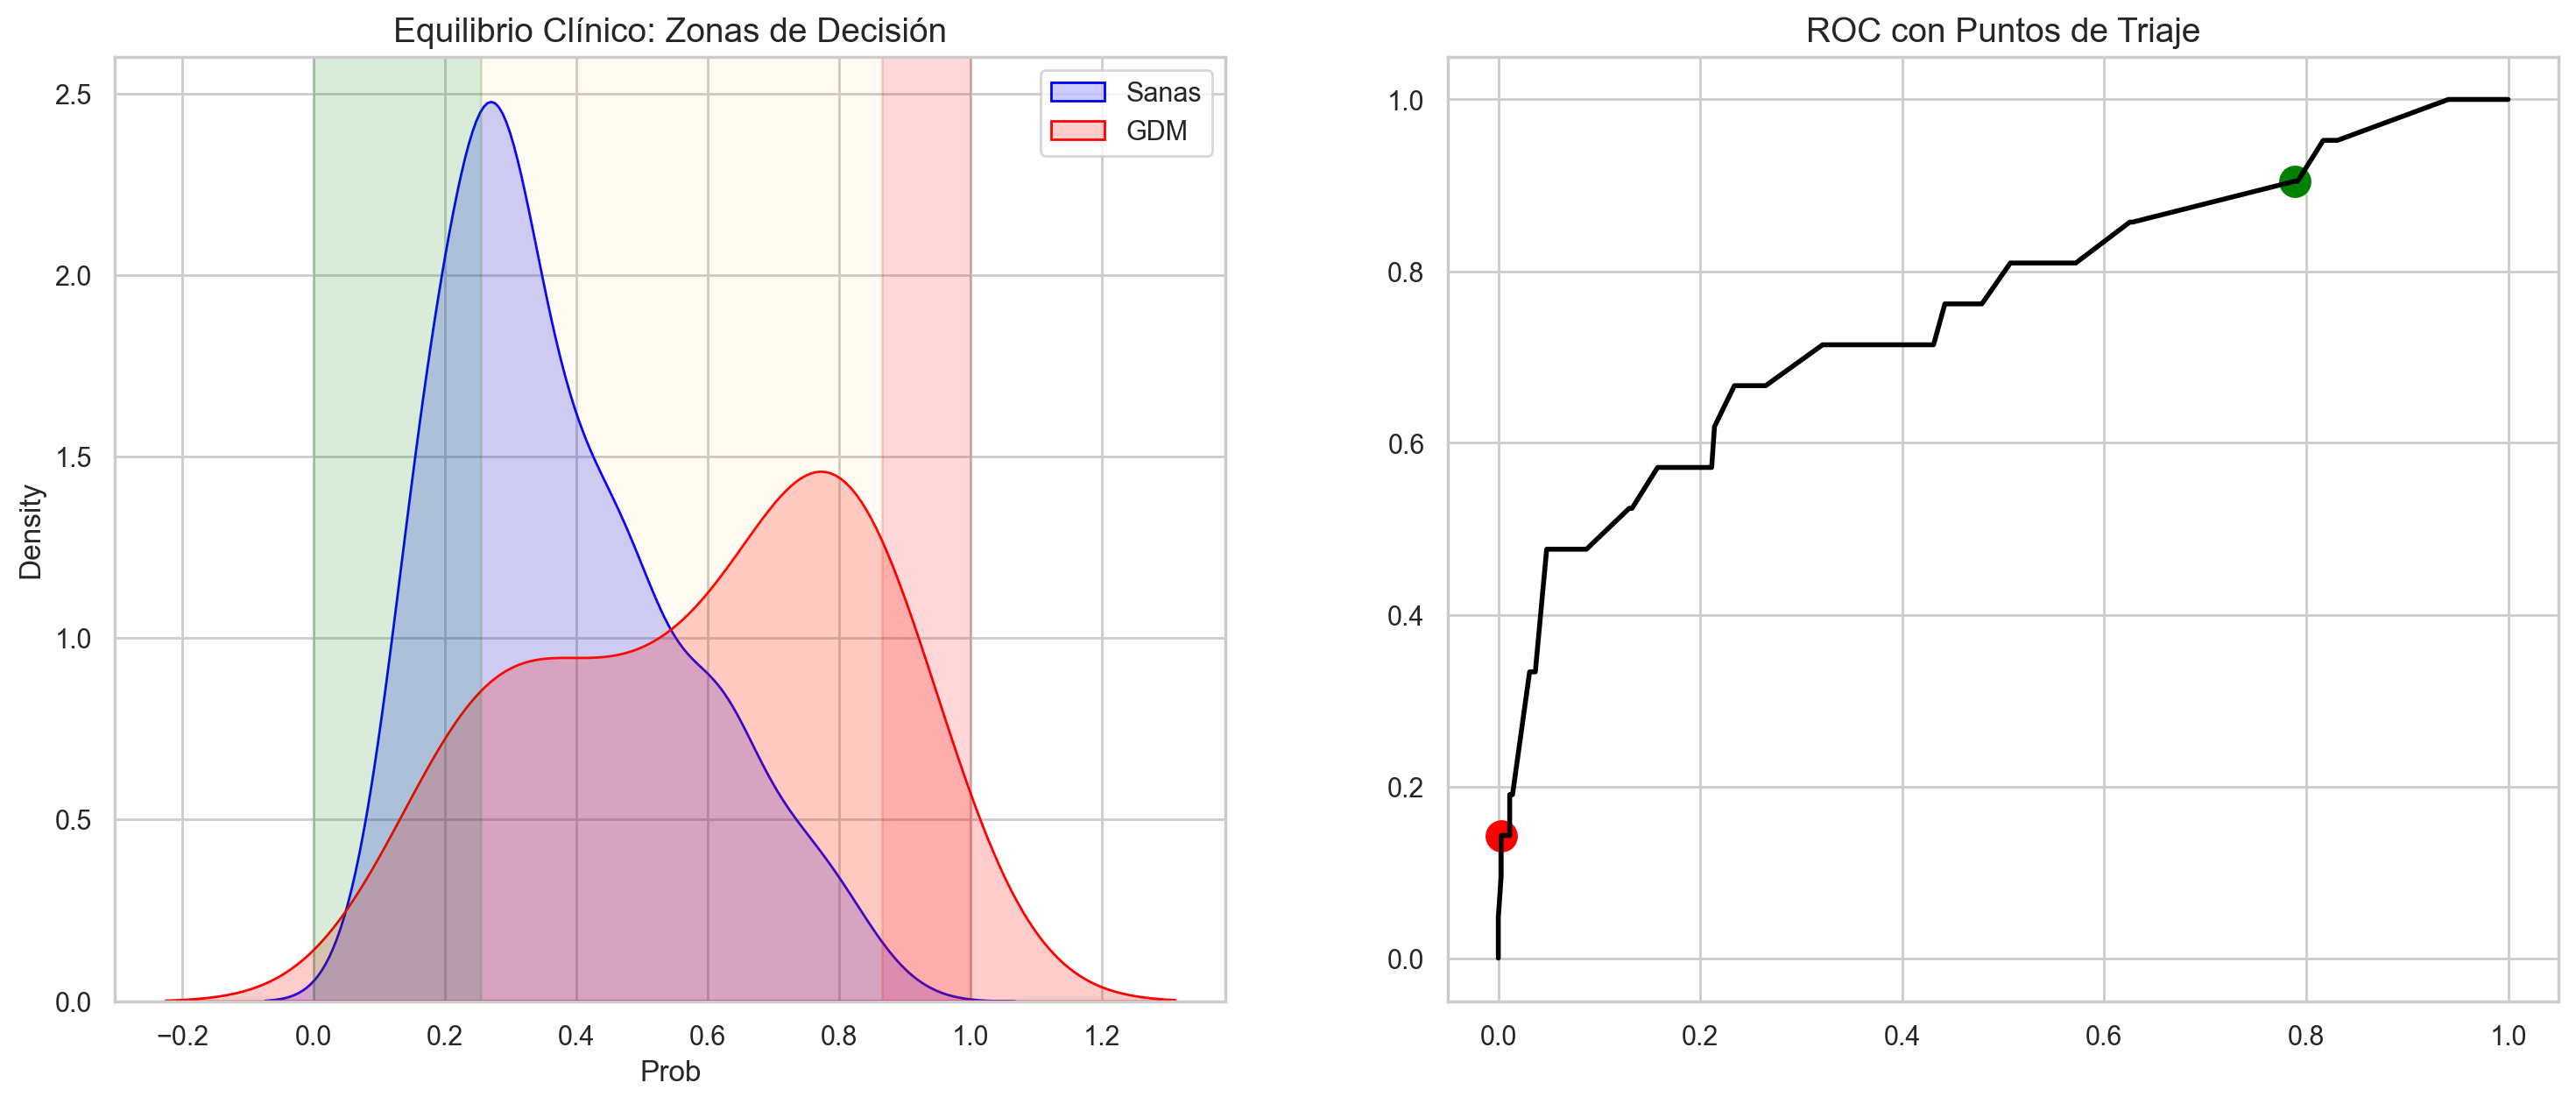


ANÁLISIS DE IMPACTO CLÍNICO EN TEST
Población total Test: 376 | Positivos Reales (GDM1=1): 21 (5.6%)
-------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL      | GDM1(+)    | % CLASE    | DESCRIPCIÓN
-------------------------------------------------------------------------------------
RULE-OUT (Descarte)       |   77 (20.5%) |    2 pts. |   2.6% | Falla en 2 pacientes (90.5% Sens)
ZONA GRIS (Sobrecarga)    |  295 (78.5%) |   16 pts. |   5.4% | Contiene al 76.2% de todas las enfermas
RULE-IN (Confirmación)    |    4 ( 1.1%) |    3 pts. |  75.0% | Precisión del 75.0% en esta zona
-------------------------------------------------------------------------------------
VALOR DEL MODELO: Se evita la prueba al 21.5% de la población del test.


In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score

# 1. Probabilidades en TEST
y_proba_test = grid_search_rl.best_estimator_.predict_proba(X_test)[:, 1]

# 2. Curvas para selección de umbrales (sobre TEST)
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_test)
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_test)

# --- PUNTOS DE COMPROMISO ---
target_sens = 0.90
idx_out = np.where(tpr >= target_sens)[0][0]
thr_out = thresholds_roc[idx_out]

target_prec = 0.70
idx_in_list = np.where(precision >= target_prec)[0]
if len(idx_in_list) > 0:
    idx_in = idx_in_list[0]
    thr_in = thresholds_pr[idx_in]
else:
    thr_in = np.percentile(y_proba_test, 90)

# 3. Categorización
def triage(p):
    if p < thr_out: return "RULE-OUT (Descarte)"
    elif p >= thr_in: return "RULE-IN (Confirmación)"
    else: return "ZONA GRIS (Sobrecarga)"

df_triage = pd.DataFrame({
    "Prob": y_proba_test,
    "Real": y_test,
    "Cat": [triage(p) for p in y_proba_test]
})

# 4. GRÁFICAS (Mantenemos la visualización anterior)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.kdeplot(data=df_triage[df_triage["Real"] == 0], x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.2)
sns.kdeplot(data=df_triage[df_triage["Real"] == 1], x="Prob", fill=True, ax=ax1, label="GDM", color="red", alpha=0.2)
ax1.axvspan(0, thr_out, color='green', alpha=0.15)
ax1.axvspan(thr_out, thr_in, color='orange', alpha=0.05)
ax1.axvspan(thr_in, 1, color='red', alpha=0.15)
ax1.set_title("Equilibrio Clínico: Zonas de Decisión", fontsize=14)
ax1.legend()

ax2.plot(fpr, tpr, color='black', lw=2)
ax2.scatter(fpr[idx_out], tpr[idx_out], color='green', s=150)
idx_roc_in = np.argmin(np.abs(thresholds_roc - thr_in))
ax2.scatter(fpr[idx_roc_in], tpr[idx_roc_in], color='red', s=150)
ax2.set_title("ROC con Puntos de Triaje", fontsize=14)
plt.show()

# 5. REPORTE FINAL CON CONTEO DE POSITIVOS
print("\n" + "="*85)
print("ANÁLISIS DE IMPACTO CLÍNICO EN TEST")
print("="*85)
total_test = len(y_test)
positivos_totales = y_test.sum()
print(f"Población total Test: {total_test} | Positivos Reales (GDM1=1): {int(positivos_totales)} ({positivos_totales/total_test:.1%})")
print("-" * 85)
print(f"{'CATEGORÍA':25s} | {'TOTAL':10s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN'}")
print("-" * 85)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    sub = df_triage[df_triage["Cat"] == cat]
    count = len(sub)
    positives = sub["Real"].sum()
    perc_total = (count / total_test) * 100
    perc_pos = (positives / count * 100) if count > 0 else 0
    
    desc = ""
    if "OUT" in cat: desc = f"Falla en {int(positives)} pacientes ({(1-positives/positivos_totales):.1%} Sens)"
    elif "IN" in cat: desc = f"Precisión del {perc_pos:.1f}% en esta zona"
    else: desc = f"Contiene al {(positives/positivos_totales):.1%} de todas las enfermas"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 85)
ahorro = ((total_test - len(df_triage[df_triage["Cat"] == "ZONA GRIS (Sobrecarga)"])) / total_test) * 100
print(f"VALOR DEL MODELO: Se evita la prueba al {ahorro:.1f}% de la población del test.")
print("="*85)

Ejecutando 50 iteraciones con optimización local de umbrales...


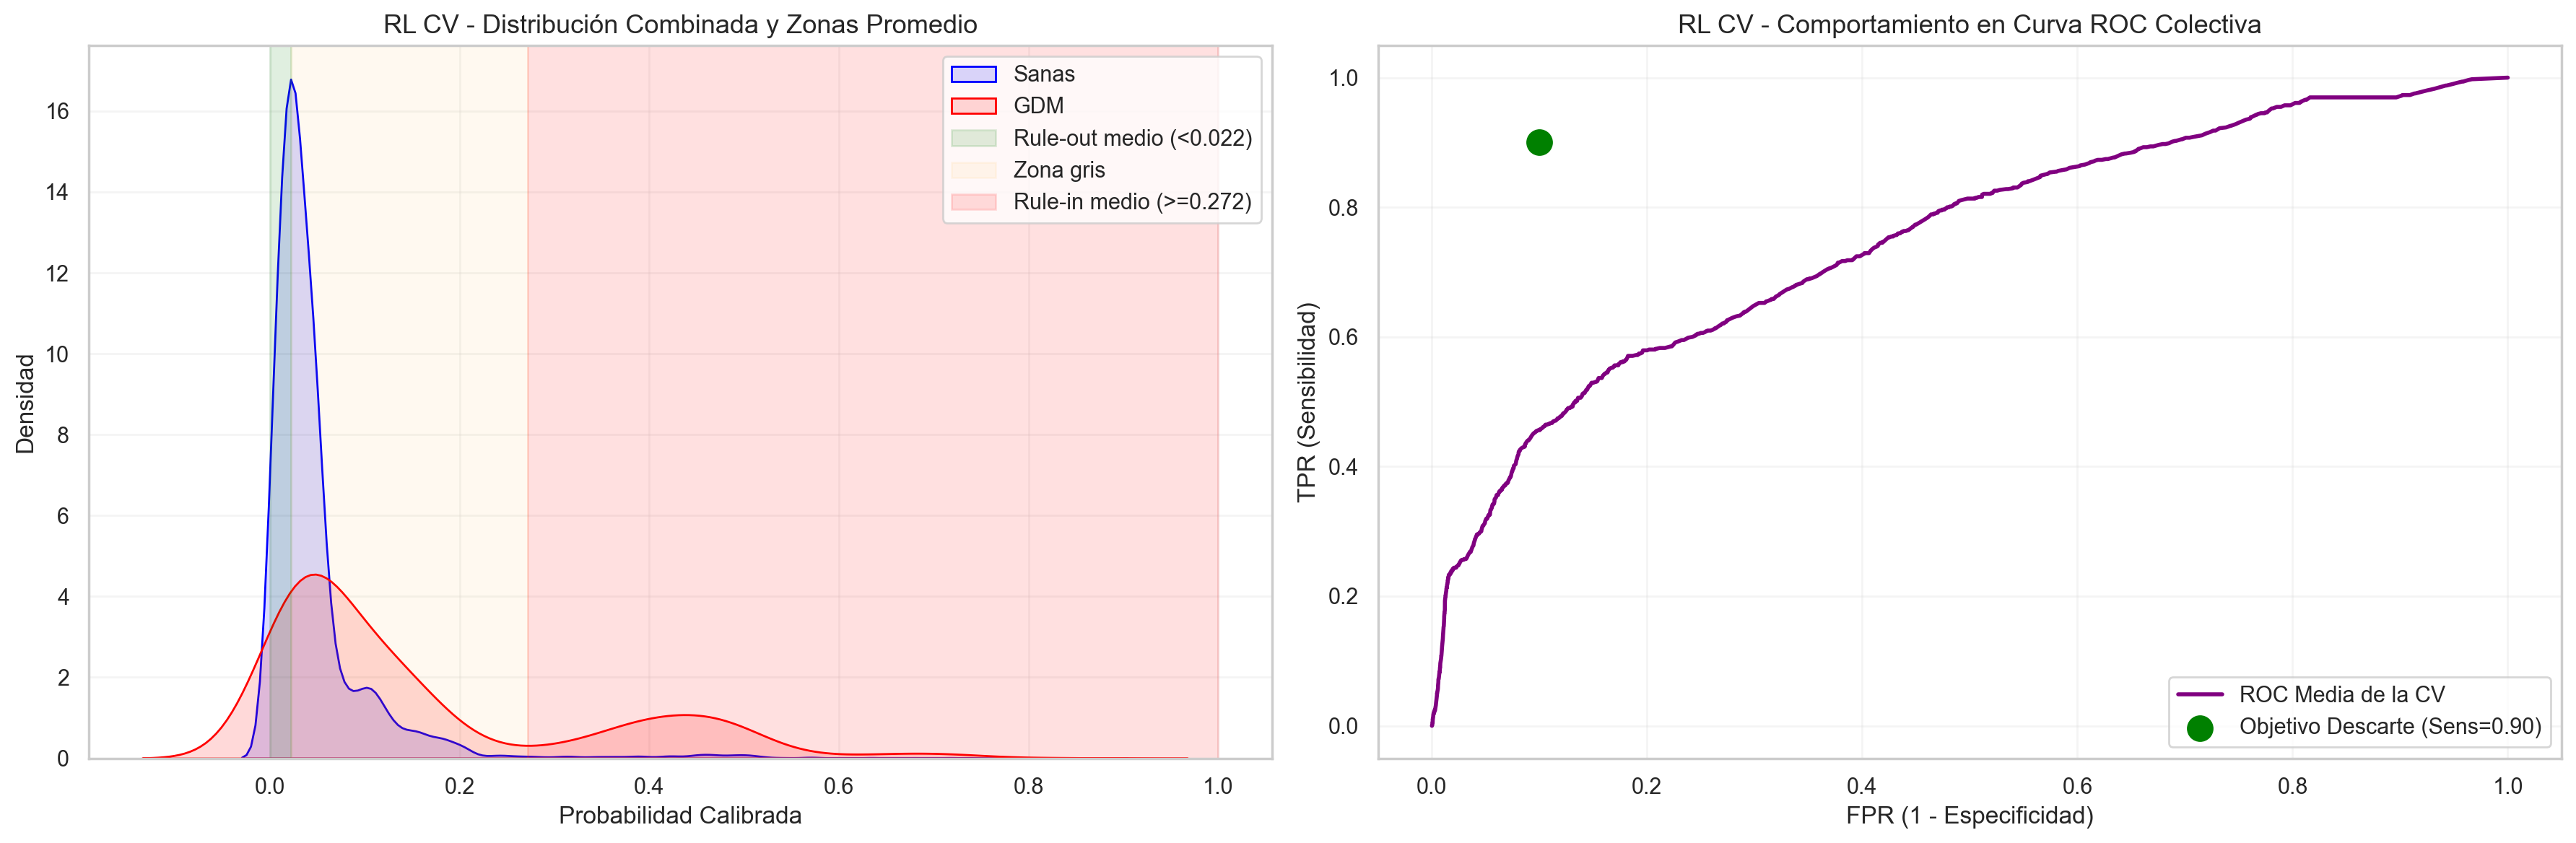


ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE (UMBRALES LOCALES) - RL
Modo de thr_in: precision
Población evaluada acumulada: 15020 | Positivos Reales Totales: 820
Umbral de Descarte Promedio: 0.0221  | Umbral de Confirmación Promedio: 0.2719
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 3738 (24.9%) |   35 pts. |   0.9% | Falla en 35 casos (95.7% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    | 10631 (70.8%) |  558 pts. |   5.2% | Absorbe al 68.0% de las enfermas
RULE-IN (Confirmación)    |  651 ( 4.3%) |  227 pts. |  34.9% | Precisión Real Consolidada del 34.9%
------------------------------------------------------------------------------------------
VALOR DEL MODELO: Se evita la prueba al 29.2% ± 12.4% de la población analizada.


In [191]:
# ======================================================================
# 6. Triaje Clínico por Validación Cruzada con dos modos de umbral
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve

# -----------------------------
# Configuración
# -----------------------------
n_splits = 5
n_repeats = 10
cv_triaje = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

# Elige el modo:
# "precision" -> calcula thr_in a partir de target_prec
# "manual"    -> usa thr_in_manual fijo
modo_thr_in = "precision"

target_sens = 0.90
target_prec = 0.4
thr_in_manual = 0.25

# -----------------------------
# Acumuladores
# -----------------------------
ahorros_folds = []
umbrales_out = []
umbrales_in = []
probas_normalizadas_grafico = []
reales_acumulados_grafico = []

total_pacientes_evaluados = 0
total_positivos_evaluados = 0
counts_globales = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"Ejecutando {n_splits * n_repeats} iteraciones con optimización local de umbrales...")
best_model = grid_search_rl.best_estimator_

for fold, (train_idx, val_idx) in enumerate(cv_triaje.split(X_train, y_train)):
    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    calibrador_fold = CalibratedClassifierCV(estimator=best_model, method="isotonic", cv=3)
    calibrador_fold.fit(X_tr_fold, y_tr_fold)

    probas_val = calibrador_fold.predict_proba(X_val_fold)[:, 1]
    y_val_arr = y_val_fold.to_numpy()

    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_arr, probas_val)
    idx_out = np.where(tpr_f >= target_sens)[0]
    thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else 0.05

    if modo_thr_in == "precision":
        precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_arr, probas_val)
        idx_in_list = np.where(precision_f >= target_prec)[0]
        if len(idx_in_list) > 0 and idx_in_list[0] < len(thresholds_pr_f):
            thr_in_f = thresholds_pr_f[idx_in_list[0]]
        else:
            thr_in_f = np.percentile(probas_val, 90)
    elif modo_thr_in == "manual":
        thr_in_f = thr_in_manual
    else:
        raise ValueError("modo_thr_in debe ser 'precision' o 'manual'")

    if thr_in_f <= thr_out_f:
        thr_in_f = thr_out_f + 0.05

    umbrales_out.append(thr_out_f)
    umbrales_in.append(thr_in_f)

    for p, real in zip(probas_val, y_val_arr):
        probas_normalizadas_grafico.append(p)
        reales_acumulados_grafico.append(real)

    cats_f = []
    for p in probas_val:
        if p < thr_out_f:
            cats_f.append("RULE-OUT (Descarte)")
        elif p >= thr_in_f:
            cats_f.append("RULE-IN (Confirmación)")
        else:
            cats_f.append("ZONA GRIS (Sobrecarga)")

    df_f = pd.DataFrame({"Real": y_val_arr, "Cat": cats_f})

    total_pacientes_evaluados += len(df_f)
    total_positivos_evaluados += int(df_f["Real"].sum())

    for c in counts_globales.keys():
        sub_c = df_f[df_f["Cat"] == c]
        counts_globales[c] += len(sub_c)
        positives_globales[c] += int(sub_c["Real"].sum())

    count_gris = len(df_f[df_f["Cat"] == "ZONA GRIS (Sobrecarga)"])
    ahorros_folds.append(((len(df_f) - count_gris) / len(df_f)) * 100)

mean_thr_out = float(np.mean(umbrales_out))
mean_thr_in = float(np.mean(umbrales_in))

df_grafico_global = pd.DataFrame({
    "Prob": probas_normalizadas_grafico,
    "Real": reales_acumulados_grafico
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global[df_grafico_global["Real"] == 0],
    x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.15, cut=3
)
sns.kdeplot(
    data=df_grafico_global[df_grafico_global["Real"] == 1],
    x="Prob", fill=True, ax=ax1, label="GDM", color="red", alpha=0.15, cut=3
)

ax1.axvspan(0, mean_thr_out, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out:.3f})")
ax1.axvspan(mean_thr_out, mean_thr_in, color="orange", alpha=0.06, label=f"Zona gris")
ax1.axvspan(mean_thr_in, 1, color="red", alpha=0.12, label=f"Rule-in medio (>={mean_thr_in:.3f})")
ax1.set_title("RL CV - Distribución Combinada y Zonas Promedio", fontsize=13)
ax1.set_xlabel("Probabilidad Calibrada")
ax1.set_ylabel("Densidad")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.2)

fpr_g, tpr_g, _ = roc_curve(df_grafico_global["Real"], df_grafico_global["Prob"])
ax2.plot(fpr_g, tpr_g, color="purple", lw=2, label="ROC Media de la CV")
ax2.scatter(1 - target_sens, target_sens, color="green", s=150, zorder=5, label=f"Objetivo Descarte (Sens={target_sens:.2f})")
ax2.set_title("RL CV - Comportamiento en Curva ROC Colectiva", fontsize=13)
ax2.set_xlabel("FPR (1 - Especificidad)")
ax2.set_ylabel("TPR (Sensibilidad)")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE (UMBRALES LOCALES) - RL")
print("=" * 90)
print(f"Modo de thr_in: {modo_thr_in}")
print(f"Población evaluada acumulada: {total_pacientes_evaluados} | Positivos Reales Totales: {int(total_positivos_evaluados)}")
print(f"Umbral de Descarte Promedio: {mean_thr_out:.4f}  | Umbral de Confirmación Promedio: {mean_thr_in:.4f}")
print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    count = counts_globales[cat]
    positives = positives_globales[cat]
    perc_total = (count / total_pacientes_evaluados) * 100 if total_pacientes_evaluados > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_promedio = (1 - positives / total_positivos_evaluados) * 100 if total_positivos_evaluados > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_promedio:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados) * 100:.1f}% de las enfermas" if total_positivos_evaluados > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {np.mean(ahorros_folds):.1f}% ± {np.std(ahorros_folds):.1f}% de la población analizada.")
print("=" * 90)

In [195]:
import numpy as np

# ==============================================================================
# EXTRAER COEFICIENTES Y ECUACIÓN DEL MODELO COMPLETO
# ==============================================================================
print("\n" + "=" * 60)
print("EXTRACCIÓN DE COEFICIENTES PARA LA ECUACIÓN DE EXPLICABILIDAD (COMPLETO)")
print("=" * 60)

# 1. Acceder al clasificador final (LogisticRegression)
# Si usas Pipeline, habitualmente es el último paso [-1] o por su nombre 'clf'
if hasattr(best_model, "named_steps"):
    try:
        lr_step = best_model.named_steps['clf']
    except KeyError:
        lr_step = best_model[-1]
else:
    lr_step = best_model

# 2. Intentar extraer los nombres de las variables binarizadas del paso previo
try:
    if hasattr(best_model, "named_steps") and 'binar' in best_model.named_steps:
        feature_names = best_model.named_steps['binar'].get_feature_names_out()
    else:
        feature_names = X_train.columns
except Exception:
    # Fallback si no se pueden recuperar, usa los del DataFrame original
    feature_names = X_train.columns

# 3. Extraer intercepto (beta_0) y coeficientes (beta_j)
beta_0 = lr_step.intercept_[0]
coefficients = lr_step.coef_[0]

print(f"Intercepto (Beta_0): {beta_0:.4f}\n")
print("Coeficientes por variable binarizada (Beta_j):")

equation_terms = []
for name, coef in zip(feature_names, coefficients):
    print(f"  - {name}: {coef:.4f}  (Odds Ratio: {np.exp(coef):.4f})")
    
    # Limpieza del nombre de la variable para que no rompa el entorno matemático de LaTeX
    clean_name = name.replace(" ", "_").replace("1t", "1T").replace("1T", "1T")
    
    # Formatear el signo y el término
    signo = "+" if coef >= 0 else "-"
    equation_terms.append(f"{signo} {abs(coef):.4f} \\cdot x_{{\\text{{{clean_name}}}}}")

# 4. Construir la ecuación final partida en dos líneas para que quepa bien en el PDF del TFG
half = len(equation_terms) // 2
line1 = " ".join(equation_terms[:half])
line2 = " ".join(equation_terms[half:])

print("\n" + "-" * 60)
print("CÓDIGO LA_TEX LISTO PARA COPIAR EN TU ECUACIÓN DE LA SUBSECCIÓN 6.3:")
print("-" * 60)
print("\\begin{equation}")
print("    \\begin{aligned}")
print(f"    z = &{beta_0:.4f} {line1} \\\\")
print(f"        {line2}")
print("    \\end{aligned}")
print("\\end{equation}")
print("=" * 60)


EXTRACCIÓN DE COEFICIENTES PARA LA ECUACIÓN DE EXPLICABILIDAD (COMPLETO)
Intercepto (Beta_0): -2.2732

Coeficientes por variable binarizada (Beta_j):
  - diabetes franca 1T: 0.0000  (Odds Ratio: 1.0000)
  - etnia: -0.1635  (Odds Ratio: 0.8492)
  - factores riesgo: 0.4961  (Odds Ratio: 1.6423)
  - edad: 0.7045  (Odds Ratio: 2.0228)
  - bmi: 0.3219  (Odds Ratio: 1.3798)
  - 1t glucosa: 0.9496  (Odds Ratio: 2.5846)
  - 1T hemoglobina glicada: 0.6770  (Odds Ratio: 1.9679)

------------------------------------------------------------
CÓDIGO LA_TEX LISTO PARA COPIAR EN TU ECUACIÓN DE LA SUBSECCIÓN 6.3:
------------------------------------------------------------
\begin{equation}
    \begin{aligned}
    z = &-2.2732 + 0.0000 \cdot x_{\text{diabetes_franca_1T}} - 0.1635 \cdot x_{\text{etnia}} + 0.4961 \cdot x_{\text{factores_riesgo}} \\
        + 0.7045 \cdot x_{\text{edad}} + 0.3219 \cdot x_{\text{bmi}} + 0.9496 \cdot x_{\text{1T_glucosa}} + 0.6770 \cdot x_{\text{1T_hemoglobina_glicada}}
   

Top-4 variables seleccionadas (RL): ['1t glucosa', '1T hemoglobina glicada', 'bmi', 'edad']
Cortes usados para RL FS: {'1t glucosa': 81.0, '1T hemoglobina glicada': 5.4, 'bmi': 30.2, 'edad': 25.0}
Ejecutando GridSearchCV sobre RL con feature selection...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Mejor ROC-AUC (CV): 0.7656
Mejores hiperparámetros: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.8, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}
Ejecutando 50 iteraciones con optimización local de umbrales para RL FS...
Selector top-4: FunctionTransformer(func=<function <lambda> at 0x000001A96AEB1800>)
Fold 01 | top-4 OK | thr_out=0.0147 | thr_in=0.1244
Fold 02 | top-4 OK | thr_out=0.0242 | thr_in=0.1354
Fold 03 | top-4 OK | thr_out=0.0146 | thr_in=0.1087
Fold 04 | top-4 OK | thr_out=0.0324 | thr_in=0.1003
Fold 05 | top-4 OK | thr_out=0.0145 | thr_in=0.1282
Fold 06 | top-4 OK | thr_out=0.0360 | thr_in=0.1019
Fold 07 | top-4 OK | thr_out=0.0389

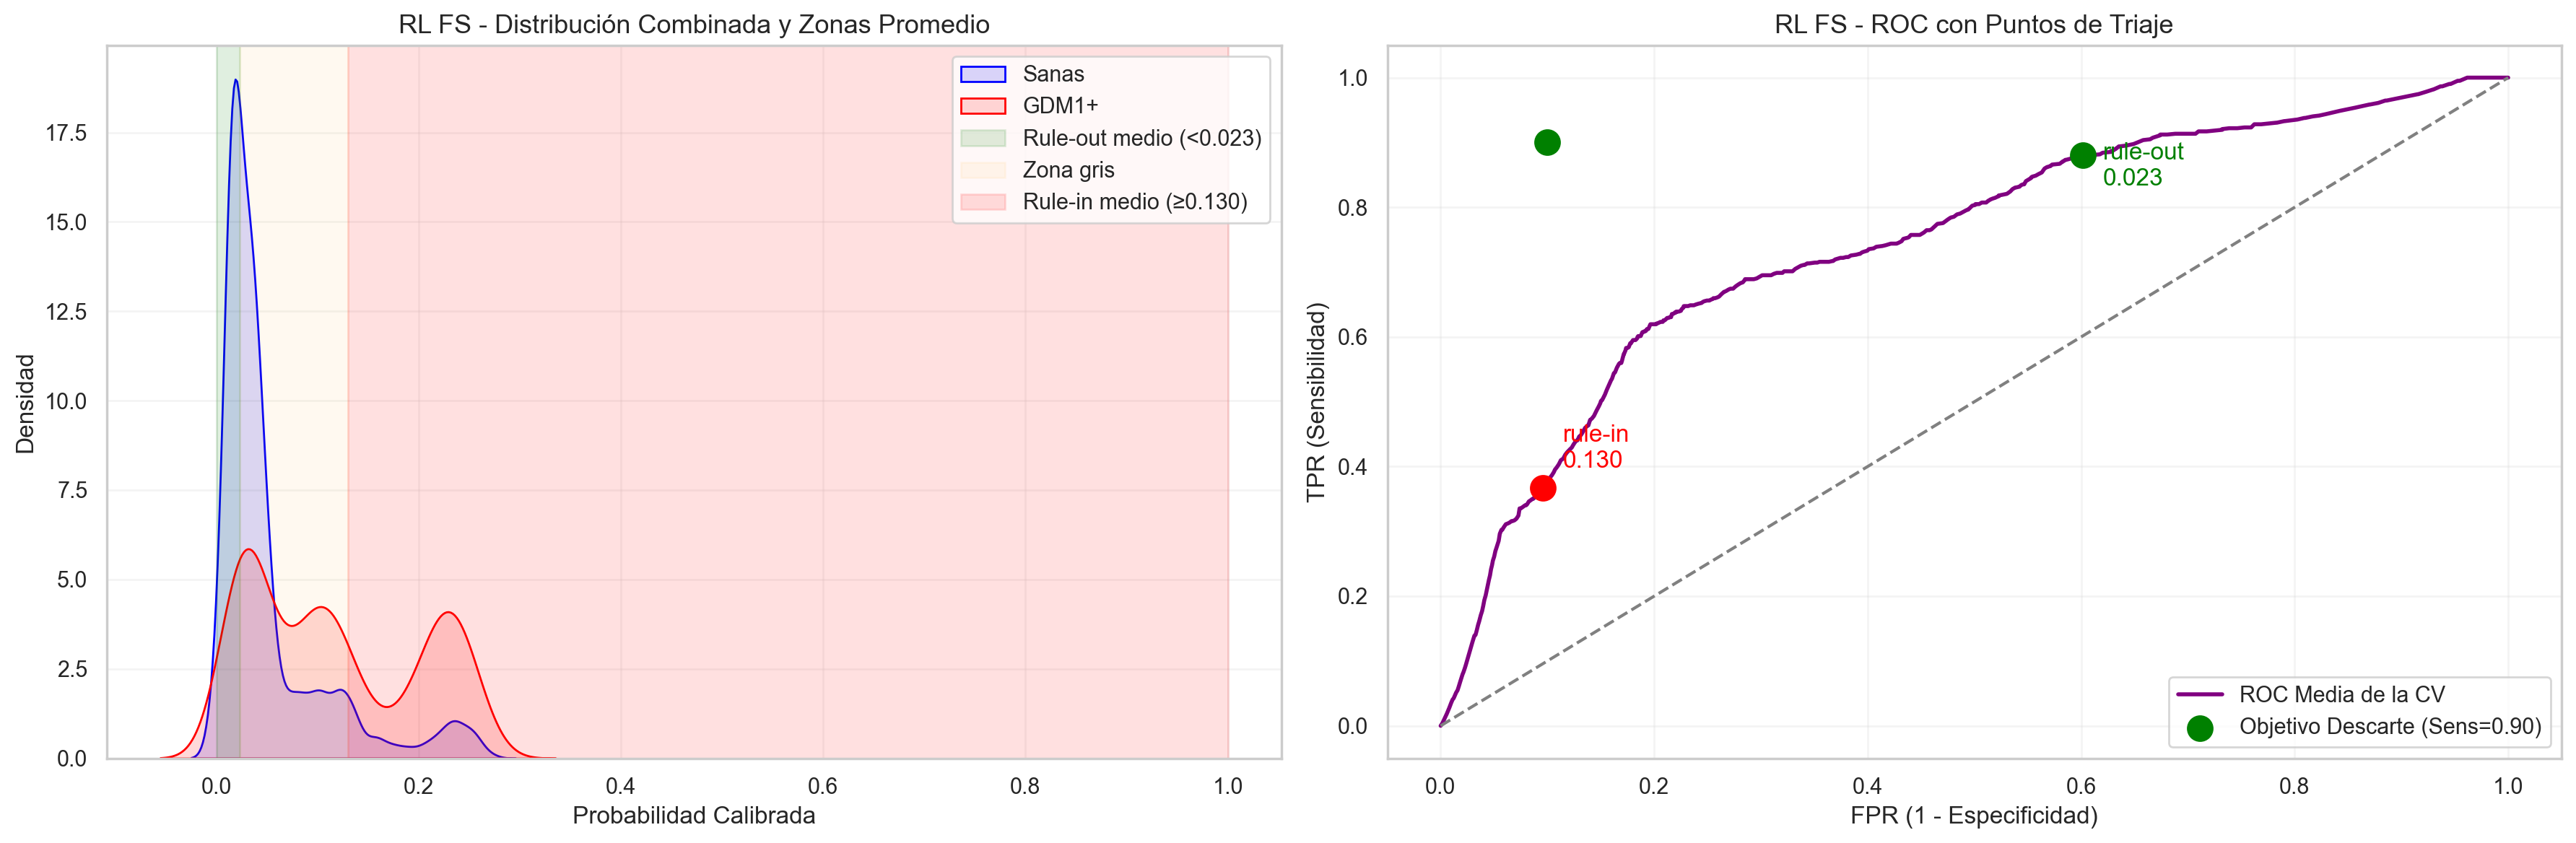


ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE (UMBRALES LOCALES) - RL FS
Top-4 usadas: ['1t glucosa', '1T hemoglobina glicada', 'bmi', 'edad']
Features top-4 sin corte definido: ninguna
Modo de thr_in: precision
Población evaluada acumulada: 15020 | Positivos Reales Totales: 820
AUC-ROC colectiva: 0.7463
Umbral de Descarte Promedio: 0.0230 ± 0.0103
Umbral de Confirmación Promedio: 0.1300 ± 0.0269
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 3335 (22.2%) |   20 pts. |   0.6% | Falla en 20 casos (97.6% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    | 9425 (62.7%) |  410 pts. |   4.4% | Absorbe al 50.0% de las enfermas
RULE-IN (Confirmación)    | 2260 (15.0%) |  390 pts. |  17.3% | Precisión Real Consolidada del 17.3%
---------------------------

In [206]:
# ======================================================================
# RL: Triaje Clínico por Validación Cruzada con dos modos de umbral - RL FS
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

# -----------------------------
# Comprobaciones previas
# -----------------------------
# buscar top-4 específico RL o global top_4_features (celda 60)
if "top_4_features_rl" in globals() and globals()["top_4_features_rl"]:
    top4_rl = list(globals()["top_4_features_rl"])
elif "top_4_features" in globals() and globals()["top_4_features"]:
    top4_rl = list(globals()["top_4_features"])
else:
    raise NameError("Primero define `top_4_features_rl` o `top_4_features` (celda 60).")

top4_rl = top_4_features
cuts_seleccionados_rl = cuts_optimos  # cortes óptimos globales

if "cuts_seleccionados_rl" not in globals():
    raise NameError("Primero define `cuts_seleccionados_rl` (cortes específicos de RL).")

assert len(top4_rl) == 4, f"Se esperaban 4 features y hay {len(top4_rl)}"
assert all(f in X_train.columns for f in top4_rl), "Alguna feature del top-4 no existe en `X_train`"

# Cortes para el top-4: usamos solo los que existan realmente en RL (aquí exigimos)
cuts_map_rl_fs = {k: cuts_seleccionados_rl[k] for k in top4_rl if k in cuts_seleccionados_rl}
missing_cuts = [k for k in top4_rl if k not in cuts_seleccionados_rl]
if missing_cuts:
    raise RuntimeError(f"Features del top-4 sin corte definido en `cuts_seleccionados_rl`: {missing_cuts}")

print("Top-4 variables seleccionadas (RL):", top4_rl)
print("Cortes usados para RL FS:", cuts_map_rl_fs)

# -----------------------------
# Pipeline + GridSearch dentro de la misma celda
# -----------------------------
# asegurar existencia de MultiThresholdBinarizer y preprocesador
if "MultiThresholdBinarizer" not in globals():
    raise NameError("No se encontró `MultiThresholdBinarizer` en el notebook.")
if "preprocesador_base_dinamico" not in globals():
    raise NameError("No se encontró `preprocesador_base_dinamico` en el notebook.")

pipe_rl_fs = Pipeline([
    ("select", FunctionTransformer(lambda X: X[top4_rl], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_rl_fs)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", LogisticRegression(random_state=42, max_iter=2000))
])

# Param grid: usa el definido en kernel si existe, si no un grid razonable
param_grid_rl = globals().get("param_grid_rl", {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["liblinear"]
})

grid_rl_fs = GridSearchCV(
    estimator=pipe_rl_fs,
    param_grid=param_grid_rl,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
    refit="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("Ejecutando GridSearchCV sobre RL con feature selection...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_rl_fs.fit(X_train, y_train)

print(f"\nMejor ROC-AUC (CV): {grid_rl_fs.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_rl_fs.best_params_}")

best_estimator_rl_fs = grid_rl_fs.best_estimator_

# obtener clon del clasificador para usarlo en pipe de CV (sin entrenar de nuevo)
if hasattr(best_estimator_rl_fs, "named_steps"):
    clf_base_rl_fs = clone(best_estimator_rl_fs.named_steps["clf"])
else:
    clf_base_rl_fs = clone(best_estimator_rl_fs)

pipe_rl_top4_cv = Pipeline([
    ("select", FunctionTransformer(lambda X: X[top4_rl], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_rl_fs)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", clf_base_rl_fs)
])

# -----------------------------
# Configuración CV de triaje
# -----------------------------
n_splits = 5
n_repeats = 10
cv_triaje_rl = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

modo_thr_in = "precision"   # "precision" o "manual"
target_sens = 0.90
target_prec = 0.50
thr_in_manual = 0.25

# -----------------------------
# Acumuladores
# -----------------------------
ahorros_folds_rl = []
umbrales_out_rl = []
umbrales_in_rl = []
probas_normalizadas_grafico_rl = []
reales_acumulados_grafico_rl = []

total_pacientes_evaluados_rl = 0
total_positivos_evaluados_rl = 0

counts_globales_rl = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales_rl = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"Ejecutando {n_splits * n_repeats} iteraciones con optimización local de umbrales para RL FS...")
print("Selector top-4:", pipe_rl_top4_cv.named_steps["select"])

# -----------------------------
# Loop CV
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(cv_triaje_rl.split(X_train, y_train), start=1):
    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    # verificaciones de integridad como en XGB
    assert list(X_tr_fold[top4_rl].columns) == top4_rl
    assert list(X_val_fold[top4_rl].columns) == top4_rl

    calibrador_fold = CalibratedClassifierCV(
        estimator=pipe_rl_top4_cv,
        method="isotonic",
        cv=3
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        calibrador_fold.fit(X_tr_fold, y_tr_fold)

    probas_val = calibrador_fold.predict_proba(X_val_fold)[:, 1]
    y_val_arr = y_val_fold.to_numpy()

    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_arr, probas_val)
    idx_out = np.where(tpr_f >= target_sens)[0]
    thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else thrs_roc_f[0]

    if modo_thr_in == "precision":
        precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_arr, probas_val)
        idx_in_list = np.where(precision_f >= target_prec)[0]
        if len(idx_in_list) > 0 and idx_in_list[0] < len(thresholds_pr_f):
            thr_in_f = thresholds_pr_f[idx_in_list[0]]
        else:
            thr_in_f = np.percentile(probas_val, 90)
    elif modo_thr_in == "manual":
        thr_in_f = thr_in_manual
    else:
        raise ValueError("modo_thr_in debe ser 'precision' o 'manual'")

    if thr_in_f <= thr_out_f:
        thr_in_f = thr_out_f + 0.05

    umbrales_out_rl.append(thr_out_f)
    umbrales_in_rl.append(thr_in_f)

    probas_normalizadas_grafico_rl.extend(probas_val.tolist())
    reales_acumulados_grafico_rl.extend(y_val_arr.tolist())

    cats_f = []
    for p in probas_val:
        if p < thr_out_f:
            cats_f.append("RULE-OUT (Descarte)")
        elif p >= thr_in_f:
            cats_f.append("RULE-IN (Confirmación)")
        else:
            cats_f.append("ZONA GRIS (Sobrecarga)")

    df_f = pd.DataFrame({"Real": y_val_arr, "Cat": cats_f})

    total_pacientes_evaluados_rl += len(df_f)
    total_positivos_evaluados_rl += int(df_f["Real"].sum())

    for c in counts_globales_rl.keys():
        sub_c = df_f[df_f["Cat"] == c]
        counts_globales_rl[c] += len(sub_c)
        positives_globales_rl[c] += int(sub_c["Real"].sum())

    count_gris = len(df_f[df_f["Cat"] == "ZONA GRIS (Sobrecarga)"])
    ahorros_folds_rl.append(((len(df_f) - count_gris) / len(df_f)) * 100)

    print(f"Fold {fold:02d} | top-4 OK | thr_out={thr_out_f:.4f} | thr_in={thr_in_f:.4f}")

# -----------------------------
# Agregados
# -----------------------------
mean_thr_out_rl = float(np.mean(umbrales_out_rl))
mean_thr_in_rl = float(np.mean(umbrales_in_rl))
std_thr_out_rl = float(np.std(umbrales_out_rl))
std_thr_in_rl = float(np.std(umbrales_in_rl))

df_grafico_global_rl = pd.DataFrame({
    "Prob": probas_normalizadas_grafico_rl,
    "Real": reales_acumulados_grafico_rl
})

auc_cv_global_rl = roc_auc_score(df_grafico_global_rl["Real"], df_grafico_global_rl["Prob"])

# -----------------------------
# Gráficas (idénticas a XGB)
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global_rl[df_grafico_global_rl["Real"] == 0],
    x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.15, cut=3
)
sns.kdeplot(
    data=df_grafico_global_rl[df_grafico_global_rl["Real"] == 1],
    x="Prob", fill=True, ax=ax1, label="GDM1+", color="red", alpha=0.15, cut=3
)

ax1.axvspan(0, mean_thr_out_rl, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out_rl:.3f})")
ax1.axvspan(mean_thr_out_rl, mean_thr_in_rl, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in_rl, 1, color="red", alpha=0.12, label=f"Rule-in medio (≥{mean_thr_in_rl:.3f})")
ax1.set_title("RL FS - Distribución Combinada y Zonas Promedio", fontsize=13)
ax1.set_xlabel("Probabilidad Calibrada")
ax1.set_ylabel("Densidad")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.2)

fpr_g, tpr_g, thresholds_g = roc_curve(df_grafico_global_rl["Real"], df_grafico_global_rl["Prob"])
ax2.plot(fpr_g, tpr_g, color="purple", lw=2, label="ROC Media de la CV")
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.scatter(1 - target_sens, target_sens, color="green", s=150, zorder=5, label=f"Objetivo Descarte (Sens={target_sens:.2f})")

idx_out_global = np.argmin(np.abs(thresholds_g - mean_thr_out_rl))
idx_in_global = np.argmin(np.abs(thresholds_g - mean_thr_in_rl))

ax2.scatter(fpr_g[idx_out_global], tpr_g[idx_out_global], color="green", s=150, zorder=6)
ax2.scatter(fpr_g[idx_in_global], tpr_g[idx_in_global], color="red", s=150, zorder=6)

ax2.annotate(
    f"rule-out\n{mean_thr_out_rl:.3f}",
    (fpr_g[idx_out_global], tpr_g[idx_out_global]),
    textcoords="offset points", xytext=(10, -15), ha="left", color="green"
)
ax2.annotate(
    f"rule-in\n{mean_thr_in_rl:.3f}",
    (fpr_g[idx_in_global], tpr_g[idx_in_global]),
    textcoords="offset points", xytext=(10, 10), ha="left", color="red"
)

ax2.set_title("RL FS - ROC con Puntos de Triaje", fontsize=13)
ax2.set_xlabel("FPR (1 - Especificidad)")
ax2.set_ylabel("TPR (Sensibilidad)")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# -----------------------------
# Reporte numérico completo
# -----------------------------
print("\n" + "=" * 90)
print("ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE (UMBRALES LOCALES) - RL FS")
print("=" * 90)
print(f"Top-4 usadas: {top4_rl}")
print(f"Features top-4 sin corte definido: {missing_cuts if missing_cuts else 'ninguna'}")
print(f"Modo de thr_in: {modo_thr_in}")
print(f"Población evaluada acumulada: {total_pacientes_evaluados_rl} | Positivos Reales Totales: {int(total_positivos_evaluados_rl)}")
print(f"AUC-ROC colectiva: {auc_cv_global_rl:.4f}")
print(f"Umbral de Descarte Promedio: {mean_thr_out_rl:.4f} ± {std_thr_out_rl:.4f}")
print(f"Umbral de Confirmación Promedio: {mean_thr_in_rl:.4f} ± {std_thr_in_rl:.4f}")
print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    count = counts_globales_rl[cat]
    positives = positives_globales_rl[cat]
    perc_total = (count / total_pacientes_evaluados_rl) * 100 if total_pacientes_evaluados_rl > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_promedio = (1 - positives / total_positivos_evaluados_rl) * 100 if total_positivos_evaluados_rl > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_promedio:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados_rl):.1%} de las enfermas" if total_positivos_evaluados_rl > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {np.mean(ahorros_folds_rl):.1f}% ± {np.std(ahorros_folds_rl):.1f}% de la población analizada.")
print("=" * 90)

In [183]:
# ==============================================================================
# EXTRAER COEFICIENTES Y ECUACIÓN PARA EL MODELO TOP-4 (TFG)
# ==============================================================================
print("\n" + "=" * 60)
print("EXTRACCIÓN DE COEFICIENTES: VARIANT TOP-4 PARSIMONIOSA")
print("=" * 60)

# Al usar feature selection mediante FunctionTransformer, accedemos al clasificador final
lr_step_top4 = best_estimator_rl_fs.named_steps['clf']

# Extraer el nombre de las columnas procesadas
try:
    feature_names_top4 = best_estimator_rl_fs.named_steps['binar'].get_feature_names_out()
except:
    # Fallback si no está implementado get_feature_names_out
    feature_names_top4 = [f"x_{f}" for f in top4_rl]

beta_0_top4 = lr_step_top4.intercept_[0]
coefficients_top4 = lr_step_top4.coef_[0]

print(f"Intercepto (Beta_0): {beta_0_top4:.4f}\n")
equation_terms_top4 = []

for name, coef in zip(feature_names_top4, coefficients_top4):
    print(f"  - {name}: {coef:.4f} (Odds Ratio: {np.exp(coef):.4f})")
    signo = "+" if coef >= 0 else "-"
    equation_terms_top4.append(f"{signo} {abs(coef):.4f} \\cdot x_{{\\text{{{name}}}}}")

latex_equation_top4 = f"z = {beta_0_top4:.4f} " + " ".join(equation_terms_top4)
print("\n" + "-" * 60)
print("SINTAXIS LA_TEX PARA SUSTITUIR EN LA ECUACIÓN DE Z (TOP-4):")
print("-" * 60)
print(latex_equation_top4)
print("=" * 60)


EXTRACCIÓN DE COEFICIENTES: VARIANT TOP-4 PARSIMONIOSA
Intercepto (Beta_0): -2.5190

  - x_1t glucosa: 0.5538 (Odds Ratio: 1.7398)
  - x_1T hemoglobina glicada: 0.5375 (Odds Ratio: 1.7118)
  - x_bmi: 0.6505 (Odds Ratio: 1.9164)
  - x_edad: 1.6486 (Odds Ratio: 5.1997)

------------------------------------------------------------
SINTAXIS LA_TEX PARA SUSTITUIR EN LA ECUACIÓN DE Z (TOP-4):
------------------------------------------------------------
z = -2.5190 + 0.5538 \cdot x_{\text{x_1t glucosa}} + 0.5375 \cdot x_{\text{x_1T hemoglobina glicada}} + 0.6505 \cdot x_{\text{x_bmi}} + 1.6486 \cdot x_{\text{x_edad}}


### Prueba modelo catalán 

Usando columnas:
- 1t glucosa > 92
- factores riesgo >= 1
Ejecutando GridSearchCV...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Mejor ROC-AUC CV: 0.6955
Mejores hiperparámetros: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}

--- EVALUACIÓN EN TEST ---
AUC test: 0.6113 | AP test: 0.1047
Counts test (out/grey/in): {'RULE-OUT (Descarte)': 0, 'ZONA GRIS (Sobrecarga)': 92, 'RULE-IN (Confirmación)': 284}
Positives test (out/grey/in): {'RULE-OUT (Descarte)': 0, 'ZONA GRIS (Sobrecarga)': 3, 'RULE-IN (Confirmación)': 18}
thr_out_test (modo=sensibilidad): 0.0182
thr_in_test (modo=precision): 0.0447


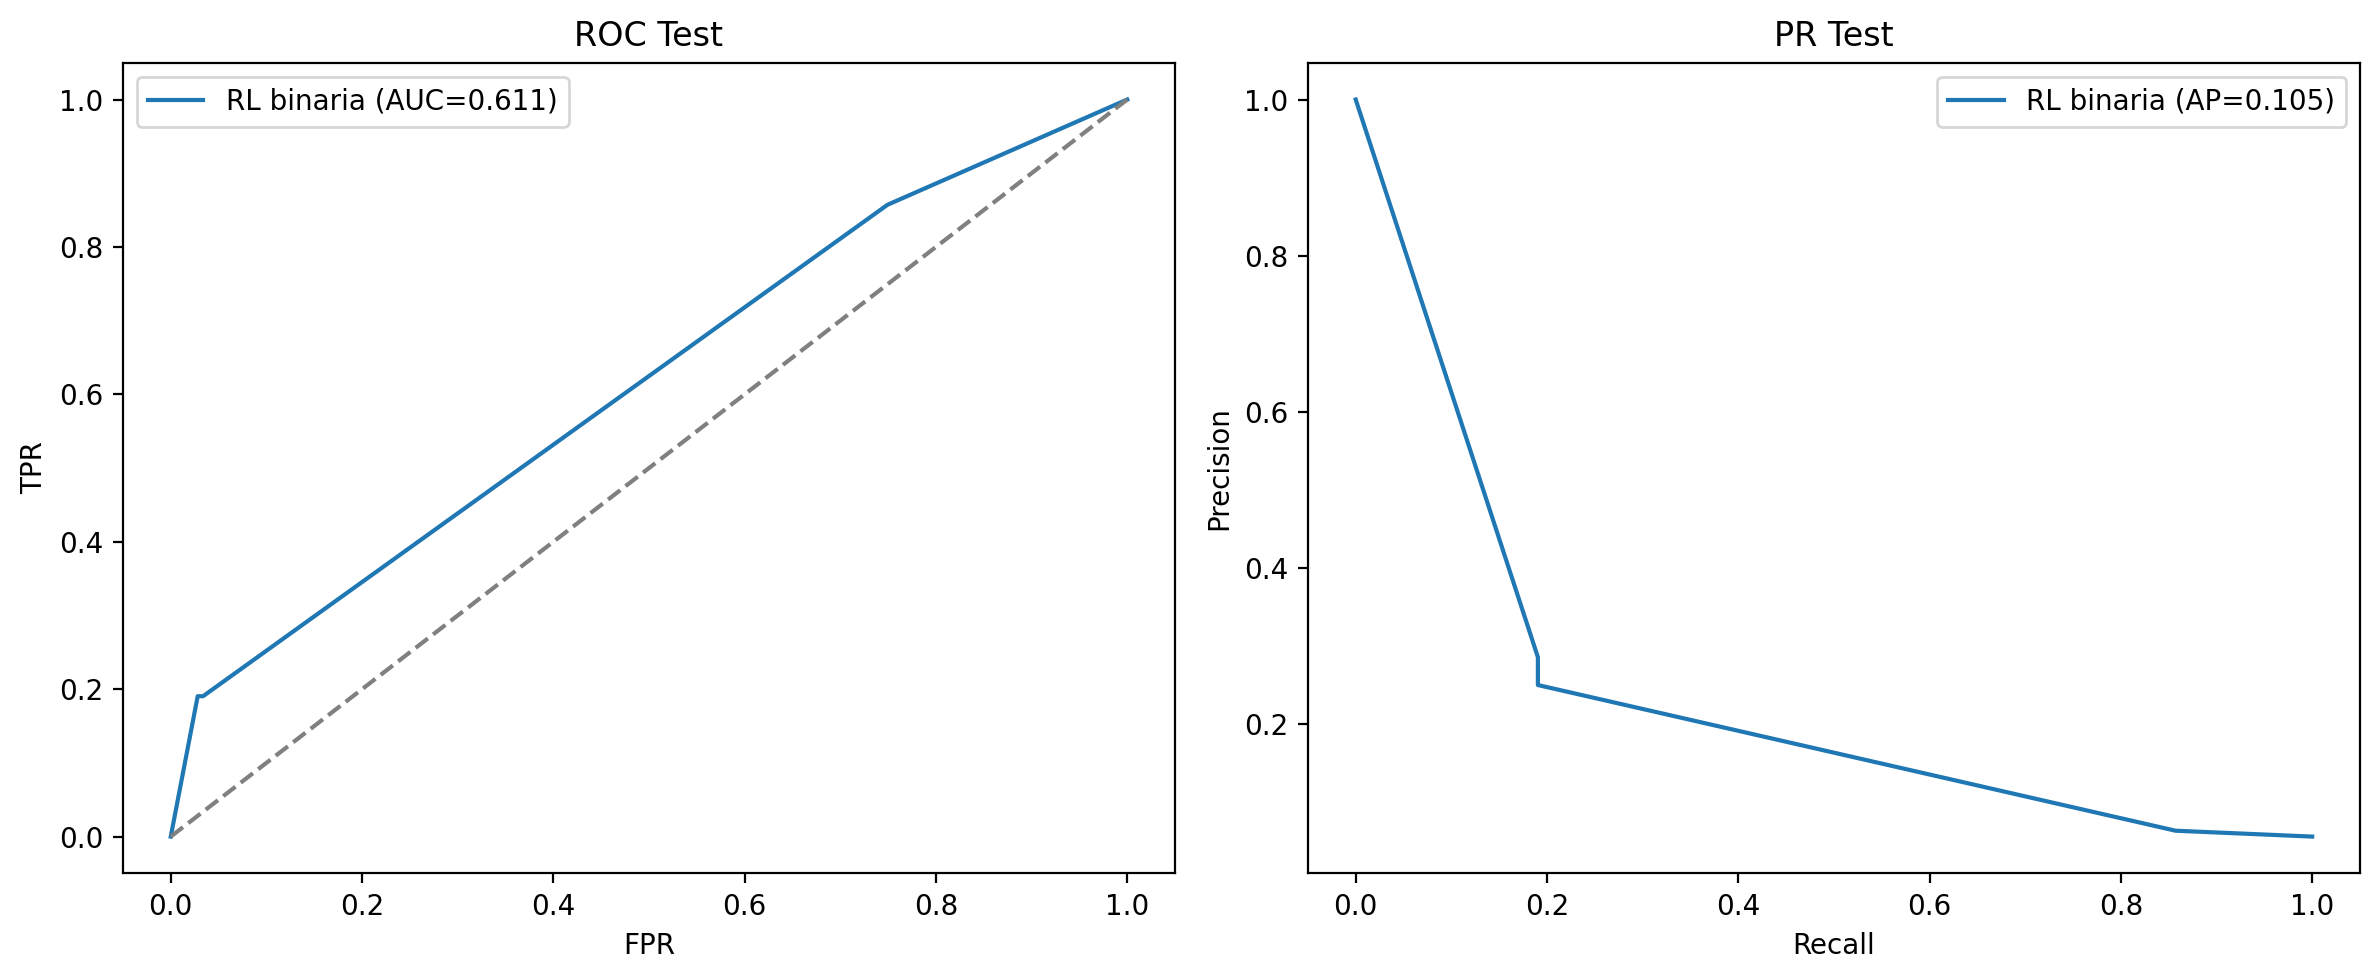

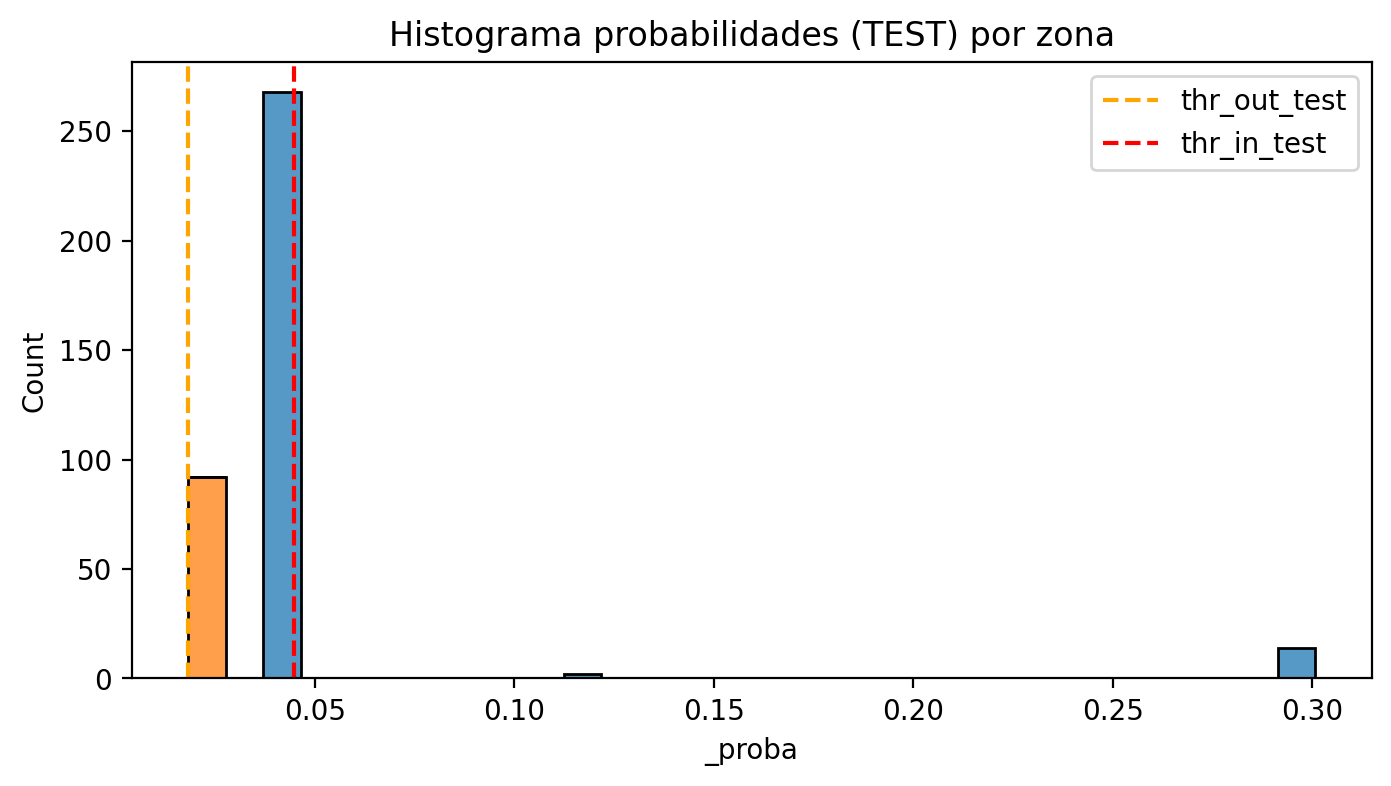


Ejecutando 100 iteraciones con la regresión logística binaria...
Fold 01 | thr_out=0.0453 | thr_in=0.0953
Fold 02 | thr_out=0.0440 | thr_in=0.0940
Fold 03 | thr_out=0.0133 | thr_in=0.0448
Fold 04 | thr_out=0.0461 | thr_in=0.0961
Fold 05 | thr_out=0.0434 | thr_in=0.0934
Fold 06 | thr_out=0.0129 | thr_in=0.0460
Fold 07 | thr_out=0.0460 | thr_in=0.0908
Fold 08 | thr_out=0.0170 | thr_in=0.0461
Fold 09 | thr_out=0.0416 | thr_in=0.0916
Fold 10 | thr_out=0.0442 | thr_in=0.0942
Fold 11 | thr_out=0.0450 | thr_in=0.0950
Fold 12 | thr_out=0.0133 | thr_in=0.0434
Fold 13 | thr_out=0.0157 | thr_in=0.0454
Fold 14 | thr_out=0.0456 | thr_in=0.0956
Fold 15 | thr_out=0.0444 | thr_in=0.0944
Fold 16 | thr_out=0.0437 | thr_in=0.0937
Fold 17 | thr_out=0.0162 | thr_in=0.0453
Fold 18 | thr_out=0.0451 | thr_in=0.0951
Fold 19 | thr_out=0.0474 | thr_in=0.2579
Fold 20 | thr_out=0.0164 | thr_in=0.0424
Fold 21 | thr_out=0.0151 | thr_in=0.0454
Fold 22 | thr_out=0.0166 | thr_in=0.0470
Fold 23 | thr_out=0.0164 | thr_i

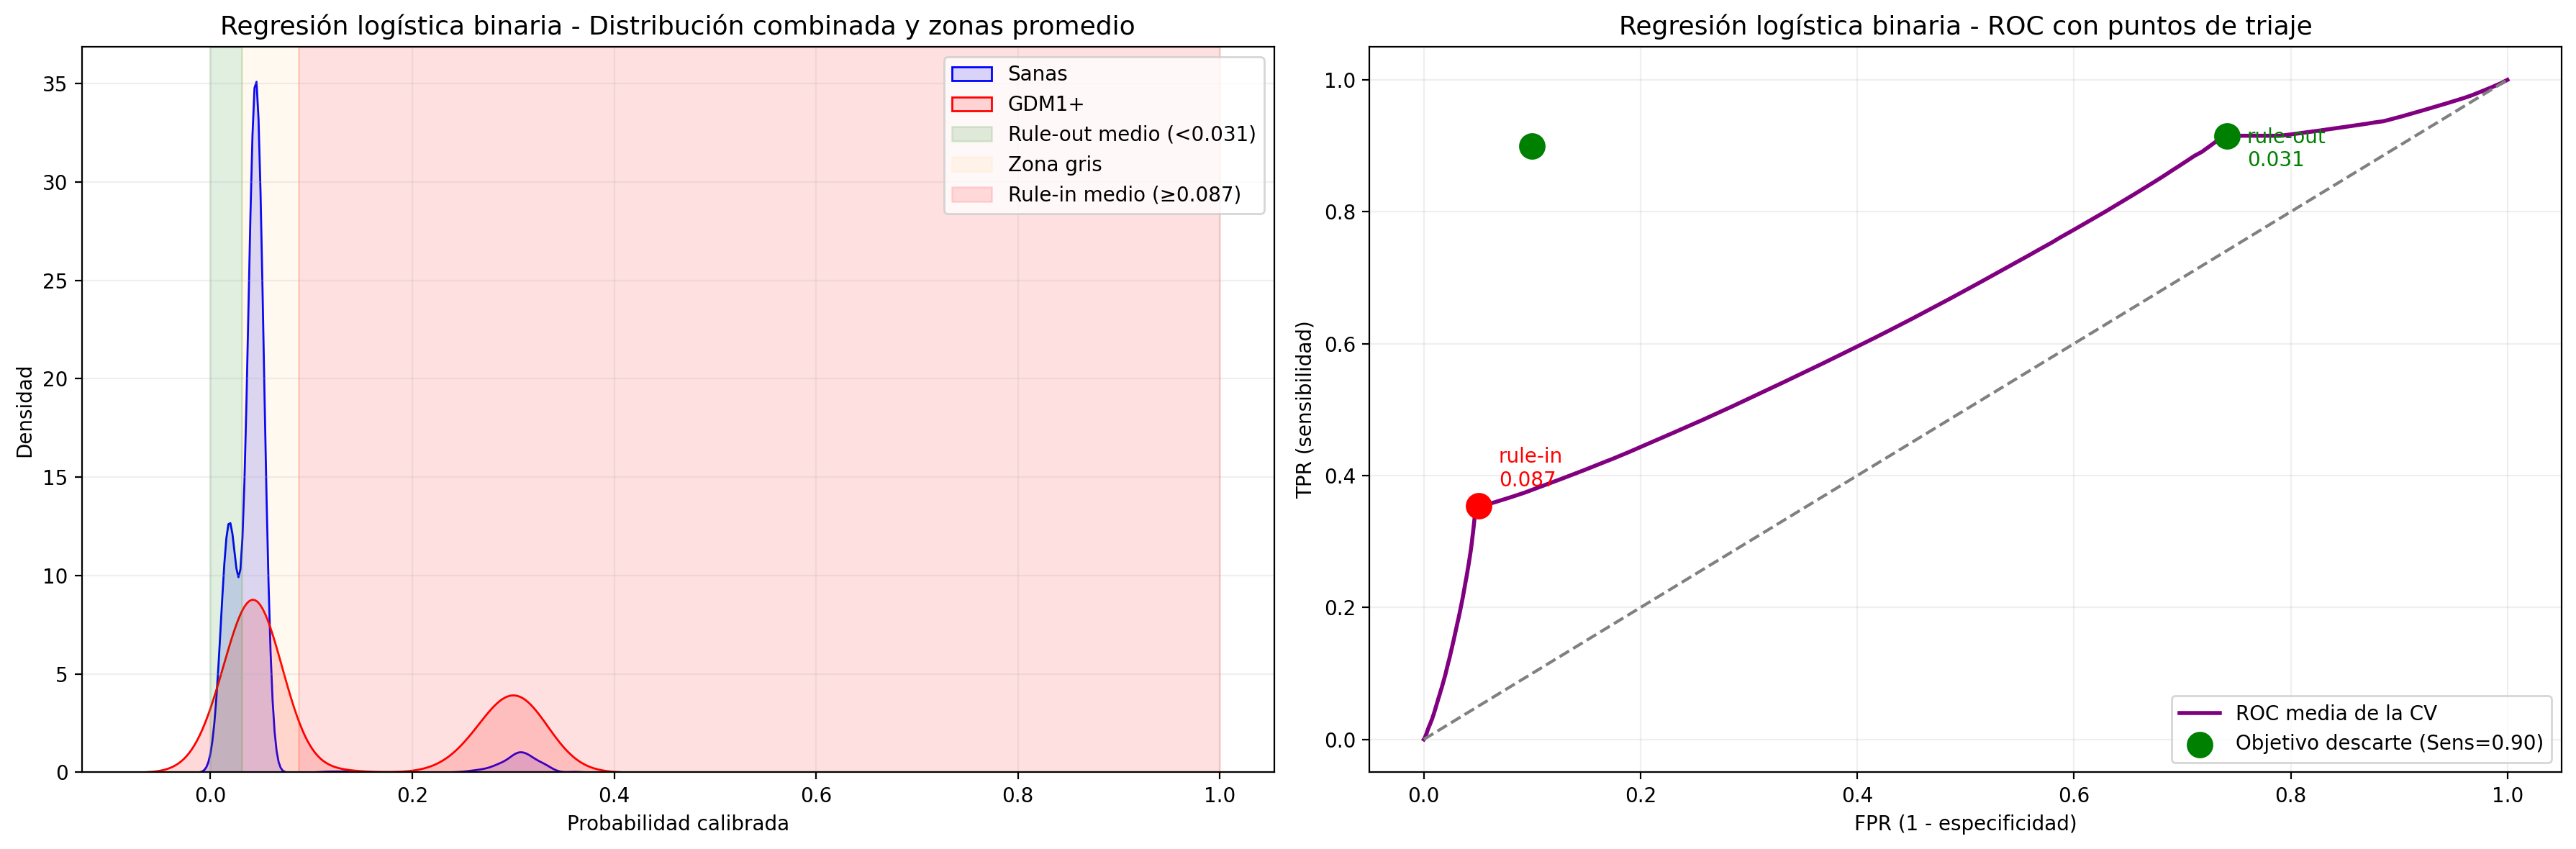


ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE - REGRESIÓN LOGÍSTICA BINARIA
Regla: 1t glucosa > 92 y factores riesgo >= 1
Población evaluada acumulada: 30040
Positivos reales totales: 1640
AUC-ROC colectiva: 0.6692
Umbral de descarte promedio: 0.0314 ± 0.0144
Umbral de confirmación promedio: 0.0872 ± 0.0532
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 4196 (14.0%) |   37 pts. |   0.9% | Falla en 37 casos (97.7% sensibilidad real)
ZONA GRIS (Sobrecarga)    | 16055 (53.4%) |  685 pts. |   4.3% | Absorbe al 41.8% de las enfermas
RULE-IN (Confirmación)    | 9789 (32.6%) |  918 pts. |   9.4% | Precisión real consolidada del 9.4%
------------------------------------------------------------------------------------------
VALOR DEL MODELO: Se evita 

In [66]:
# ======================================================================
# Regresión logística binaria con:
#   - glucosa > 92
#   - factores riesgo >= 1
# + thr_out manual opcional
# + test + CV-triaje con plots
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone

warnings.filterwarnings("ignore")

# -----------------------------
# Columnas concretas
# -----------------------------
def _pick_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col
    raise NameError(f"No se encontró ninguna columna válida para {label}. Probé: {candidates}")

glucosa_col = _pick_column(X_train, ["glucosa", "1t glucosa", "Glucosa"], "glucosa")
riesgo_col = _pick_column(X_train, ["factores riesgo", "Factores Riesgo"], "factores riesgo")

print("Usando columnas:")
print(f"- {glucosa_col} > 92")
print(f"- {riesgo_col} >= 1")

# -----------------------------
# Cortes binarios específicos
# -----------------------------
cuts_map_rl = {
    glucosa_col: 92,
    riesgo_col: 1
}

# -----------------------------
# Pipeline base
# -----------------------------
if "MultiThresholdBinarizer" not in globals():
    raise NameError("No se encontró `MultiThresholdBinarizer` en el notebook.")
if "preprocesador_base_dinamico" not in globals():
    raise NameError("No se encontró `preprocesador_base_dinamico` en el notebook.")

pipe_rl_bin = Pipeline([
    ("select", FunctionTransformer(lambda X: X[[glucosa_col, riesgo_col]], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_rl)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

# -----------------------------
# GridSearch
# -----------------------------
param_grid_rl = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["liblinear"]
}

grid_rl = GridSearchCV(
    estimator=pipe_rl_bin,
    param_grid=param_grid_rl,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
    refit="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("Ejecutando GridSearchCV...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_rl.fit(X_train, y_train)

print(f"\nMejor ROC-AUC CV: {grid_rl.best_score_:.4f}")
print("Mejores hiperparámetros:", grid_rl.best_params_)

best_estimator_rl = grid_rl.best_estimator_

# pipeline para CV-triaje
pipe_rl_cv = Pipeline([
    ("select", FunctionTransformer(lambda X: X[[glucosa_col, riesgo_col]], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_rl)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", clone(best_estimator_rl.named_steps["clf"]))
])

# -----------------------------
# Configuración de umbrales
# -----------------------------
target_sens = globals().get("target_sens", 0.90)
target_prec = globals().get("target_prec", 0.40)
modo_thr_in = globals().get("modo_thr_in", "manual")
thr_in_manual = globals().get("thr_in_manual", 0.25)

modo_thr_out = globals().get("modo_thr_out", "sensibilidad")  # "manual" o "sensibilidad"
thr_out_manual = globals().get("thr_out_manual", 0.20)

# -----------------------------
# Evaluación en TEST
# -----------------------------
calibrador_test = CalibratedClassifierCV(best_estimator_rl, method="isotonic", cv=3)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    calibrador_test.fit(X_train, y_train)

probs_test = calibrador_test.predict_proba(X_test)[:, 1]
auc_test_rl = roc_auc_score(y_test, probs_test)
ap_test_rl = average_precision_score(y_test, probs_test)

fpr_t, tpr_t, thr_roc_t = roc_curve(y_test, probs_test)


modo_thr_in = "precision"
modo_thr_out = "sensibilidad"
if modo_thr_out == "manual":
    thr_out_test = thr_out_manual
else:
    idx_out_t = np.where(tpr_t >= target_sens)[0]
    thr_out_test = thr_roc_t[idx_out_t[0]] if len(idx_out_t) > 0 else thr_roc_t[0]

precision_t, recall_t, thr_pr_t = precision_recall_curve(y_test, probs_test)
if modo_thr_in == "precision":
    idx_in_t = np.where(precision_t >= target_prec)[0]
    if len(idx_in_t) > 0 and idx_in_t[0] < len(thr_pr_t):
        thr_in_test = thr_pr_t[idx_in_t[0]]
    else:
        thr_in_test = np.percentile(probs_test, 90)
else:
    thr_in_test = thr_in_manual

if thr_in_test <= thr_out_test:
    thr_in_test = thr_out_test + 0.05

out_mask = probs_test < thr_out_test
in_mask = probs_test >= thr_in_test
grey_mask = (probs_test >= thr_out_test) & (probs_test < thr_in_test)

counts_test = {
    "RULE-OUT (Descarte)": int(out_mask.sum()),
    "ZONA GRIS (Sobrecarga)": int(grey_mask.sum()),
    "RULE-IN (Confirmación)": int(in_mask.sum())
}
positives_test = {
    "RULE-OUT (Descarte)": int(y_test.iloc[out_mask.nonzero()[0]].sum()) if out_mask.any() else 0,
    "ZONA GRIS (Sobrecarga)": int(y_test.iloc[grey_mask.nonzero()[0]].sum()) if grey_mask.any() else 0,
    "RULE-IN (Confirmación)": int(y_test.iloc[in_mask.nonzero()[0]].sum()) if in_mask.any() else 0
}

print("\n--- EVALUACIÓN EN TEST ---")
print(f"AUC test: {auc_test_rl:.4f} | AP test: {ap_test_rl:.4f}")
print("Counts test (out/grey/in):", counts_test)
print("Positives test (out/grey/in):", positives_test)
print(f"thr_out_test (modo={modo_thr_out}): {thr_out_test:.4f}")
print(f"thr_in_test (modo={modo_thr_in}): {thr_in_test:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_t, tpr_t, label=f"RL binaria (AUC={auc_test_rl:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Test")
plt.legend()

plt.subplot(1, 2, 2)
prec_t, rec_t, _ = precision_recall_curve(y_test, probs_test)
plt.plot(rec_t, prec_t, label=f"RL binaria (AP={ap_test_rl:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Test")
plt.legend()
plt.tight_layout()
plt.show()

df_test = X_test.copy()
df_test["_y"] = y_test.values
df_test["_proba"] = probs_test
df_test["_zone"] = "RULE-OUT (Descarte)"
df_test.loc[grey_mask, "_zone"] = "ZONA GRIS (Sobrecarga)"
df_test.loc[in_mask, "_zone"] = "RULE-IN (Confirmación)"

plt.figure(figsize=(8, 4))
sns.histplot(data=df_test, x="_proba", hue="_zone", bins=30, stat="count", multiple="stack")
plt.axvline(thr_out_test, color="orange", linestyle="--", label="thr_out_test")
plt.axvline(thr_in_test, color="red", linestyle="--", label="thr_in_test")
plt.title("Histograma probabilidades (TEST) por zona")
plt.legend()
plt.show()

# -----------------------------
# CV-triaje
# -----------------------------
n_splits = 5
n_repeats = 20
cv_triaje_rl = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

ahorros_folds_rl = []
umbrales_out_rl = []
umbrales_in_rl = []
probas_normalizadas_grafico_rl = []
reales_acumulados_grafico_rl = []

total_pacientes_evaluados_rl = 0
total_positivos_evaluados_rl = 0

counts_globales_rl = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales_rl = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"\nEjecutando {n_splits * n_repeats} iteraciones con la regresión logística binaria...")
for fold, (train_idx, val_idx) in enumerate(cv_triaje_rl.split(X_train, y_train), start=1):
    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    calibrador_fold = CalibratedClassifierCV(
        estimator=clone(pipe_rl_cv),
        method="isotonic",
        cv=3
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        calibrador_fold.fit(X_tr_fold, y_tr_fold)

    probas_val = calibrador_fold.predict_proba(X_val_fold)[:, 1]
    y_val_arr = y_val_fold.to_numpy()

    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_arr, probas_val)

    if modo_thr_out == "manual":
        thr_out_f = thr_out_manual
    else:
        idx_out = np.where(tpr_f >= target_sens)[0]
        thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else thrs_roc_f[0]

    if modo_thr_in == "precision":
        precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_arr, probas_val)
        idx_in_list = np.where(precision_f >= target_prec)[0]
        if len(idx_in_list) > 0 and idx_in_list[0] < len(thresholds_pr_f):
            thr_in_f = thresholds_pr_f[idx_in_list[0]]
        else:
            thr_in_f = np.percentile(probas_val, 90)
    else:
        thr_in_f = thr_in_manual

    if thr_in_f <= thr_out_f:
        thr_in_f = thr_out_f + 0.05

    umbrales_out_rl.append(thr_out_f)
    umbrales_in_rl.append(thr_in_f)

    probas_normalizadas_grafico_rl.extend(probas_val.tolist())
    reales_acumulados_grafico_rl.extend(y_val_arr.tolist())

    cats_f = []
    for p in probas_val:
        if p < thr_out_f:
            cats_f.append("RULE-OUT (Descarte)")
        elif p >= thr_in_f:
            cats_f.append("RULE-IN (Confirmación)")
        else:
            cats_f.append("ZONA GRIS (Sobrecarga)")

    df_f = pd.DataFrame({"Real": y_val_arr, "Cat": cats_f})

    total_pacientes_evaluados_rl += len(df_f)
    total_positivos_evaluados_rl += int(df_f["Real"].sum())

    for c in counts_globales_rl.keys():
        sub_c = df_f[df_f["Cat"] == c]
        counts_globales_rl[c] += len(sub_c)
        positives_globales_rl[c] += int(sub_c["Real"].sum())

    count_gris = len(df_f[df_f["Cat"] == "ZONA GRIS (Sobrecarga)"])
    ahorros_folds_rl.append(((len(df_f) - count_gris) / len(df_f)) * 100)

    print(f"Fold {fold:02d} | thr_out={thr_out_f:.4f} | thr_in={thr_in_f:.4f}")

mean_thr_out_rl = float(np.mean(umbrales_out_rl))
mean_thr_in_rl = float(np.mean(umbrales_in_rl))
std_thr_out_rl = float(np.std(umbrales_out_rl))
std_thr_in_rl = float(np.std(umbrales_in_rl))

df_grafico_global_rl = pd.DataFrame({
    "Prob": probas_normalizadas_grafico_rl,
    "Real": reales_acumulados_grafico_rl
})

auc_cv_global_rl = roc_auc_score(df_grafico_global_rl["Real"], df_grafico_global_rl["Prob"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global_rl[df_grafico_global_rl["Real"] == 0],
    x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.15, cut=3
)
sns.kdeplot(
    data=df_grafico_global_rl[df_grafico_global_rl["Real"] == 1],
    x="Prob", fill=True, ax=ax1, label="GDM1+", color="red", alpha=0.15, cut=3
)

ax1.axvspan(0, mean_thr_out_rl, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out_rl:.3f})")
ax1.axvspan(mean_thr_out_rl, mean_thr_in_rl, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in_rl, 1, color="red", alpha=0.12, label=f"Rule-in medio (≥{mean_thr_in_rl:.3f})")
ax1.set_title("Regresión logística binaria - Distribución combinada y zonas promedio", fontsize=13)
ax1.set_xlabel("Probabilidad calibrada")
ax1.set_ylabel("Densidad")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.2)

fpr_g, tpr_g, thresholds_g = roc_curve(df_grafico_global_rl["Real"], df_grafico_global_rl["Prob"])
ax2.plot(fpr_g, tpr_g, color="purple", lw=2, label="ROC media de la CV")
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.scatter(1 - target_sens, target_sens, color="green", s=150, zorder=5, label=f"Objetivo descarte (Sens={target_sens:.2f})")

idx_out_global = np.argmin(np.abs(thresholds_g - mean_thr_out_rl))
idx_in_global = np.argmin(np.abs(thresholds_g - mean_thr_in_rl))

ax2.scatter(fpr_g[idx_out_global], tpr_g[idx_out_global], color="green", s=150, zorder=6)
ax2.scatter(fpr_g[idx_in_global], tpr_g[idx_in_global], color="red", s=150, zorder=6)

ax2.annotate(
    f"rule-out\n{mean_thr_out_rl:.3f}",
    (fpr_g[idx_out_global], tpr_g[idx_out_global]),
    textcoords="offset points", xytext=(10, -15), ha="left", color="green"
)
ax2.annotate(
    f"rule-in\n{mean_thr_in_rl:.3f}",
    (fpr_g[idx_in_global], tpr_g[idx_in_global]),
    textcoords="offset points", xytext=(10, 10), ha="left", color="red"
)

ax2.set_title("Regresión logística binaria - ROC con puntos de triaje", fontsize=13)
ax2.set_xlabel("FPR (1 - especificidad)")
ax2.set_ylabel("TPR (sensibilidad)")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE - REGRESIÓN LOGÍSTICA BINARIA")
print("=" * 90)
print(f"Regla: {glucosa_col} > 92 y {riesgo_col} >= 1")
print(f"Población evaluada acumulada: {total_pacientes_evaluados_rl}")
print(f"Positivos reales totales: {int(total_positivos_evaluados_rl)}")
print(f"AUC-ROC colectiva: {auc_cv_global_rl:.4f}")
print(f"Umbral de descarte promedio: {mean_thr_out_rl:.4f} ± {std_thr_out_rl:.4f}")
print(f"Umbral de confirmación promedio: {mean_thr_in_rl:.4f} ± {std_thr_in_rl:.4f}")
print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    count = counts_globales_rl[cat]
    positives = positives_globales_rl[cat]
    perc_total = (count / total_pacientes_evaluados_rl) * 100 if total_pacientes_evaluados_rl > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_promedio = (1 - positives / total_positivos_evaluados_rl) * 100 if total_positivos_evaluados_rl > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_promedio:.1f}% sensibilidad real)"
    elif "IN" in cat:
        desc = f"Precisión real consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados_rl):.1%} de las enfermas" if total_positivos_evaluados_rl > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {np.mean(ahorros_folds_rl):.1f}% ± {np.std(ahorros_folds_rl):.1f}% de la población analizada.")
print("=" * 90)

In [67]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold

# =============================
# Regla clínica: glucosa > 92 y factores riesgo >= 1
# =============================
def _pick_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col
    raise NameError(f"No se encontró ninguna columna válida para {label}. Probé: {candidates}")

glucosa_col = _pick_column(X_train, ["glucosa", "1t glucosa", "Glucosa"], "glucosa")
riesgo_col = _pick_column(X_train, ["factores riesgo", "Factores Riesgo"], "factores riesgo")

gluc_thr = 92
riesgo_thr = 1

print(f"Regla: {glucosa_col} > {gluc_thr} y {riesgo_col} >= {riesgo_thr}")

# =============================
# CV
# =============================
n_splits = 5
n_repeats = 20
cv_rule = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

fold_rows = []

for fold, (_, val_idx) in enumerate(cv_rule.split(X_train, y_train), start=1):
    X_val = X_train.iloc[val_idx]
    y_val = np.asarray(y_train.iloc[val_idx])

    gluc = pd.to_numeric(X_val[glucosa_col], errors="coerce")
    riesgo = pd.to_numeric(X_val[riesgo_col], errors="coerce")

    rule_in = ((gluc > gluc_thr) & (riesgo >= riesgo_thr)).to_numpy()
    rule_out = ~rule_in

    n_total = len(val_idx)
    n_pos = int((y_val == 1).sum())
    n_neg = int((y_val == 0).sum())

    n_in = int(rule_in.sum())
    n_out = int(rule_out.sum())

    pos_in = int(((rule_in == 1) & (y_val == 1)).sum())
    pos_out = int(((rule_out == 1) & (y_val == 1)).sum())

    prec_in = pos_in / n_in if n_in > 0 else np.nan
    sens_real_out = 1 - (pos_out / n_pos) if n_pos > 0 else np.nan
    pct_class_in = pos_in / n_pos if n_pos > 0 else np.nan
    pct_class_out = pos_out / n_pos if n_pos > 0 else np.nan

    fold_rows.append({
        "fold": fold,
        "n_total": n_total,
        "n_pos": n_pos,
        "n_in": n_in,
        "n_out": n_out,
        "pos_in": pos_in,
        "pos_out": pos_out,
        "pct_in": n_in / n_total,
        "pct_out": n_out / n_total,
        "prec_in": prec_in,
        "sens_real_out": sens_real_out,
        "pct_class_in": pct_class_in,
        "pct_class_out": pct_class_out,
    })

df_cv = pd.DataFrame(fold_rows)

def ms(x):
    x = np.asarray(x, dtype=float)
    return np.nanmean(x), np.nanstd(x)

mean_in, std_in = ms(df_cv["n_in"])
mean_out, std_out = ms(df_cv["n_out"])
mean_pos_in, std_pos_in = ms(df_cv["pos_in"])
mean_pos_out, std_pos_out = ms(df_cv["pos_out"])
mean_pct_in, std_pct_in = ms(df_cv["pct_in"] * 100)
mean_pct_out, std_pct_out = ms(df_cv["pct_out"] * 100)
mean_prec_in, std_prec_in = ms(df_cv["prec_in"] * 100)
mean_sens_out, std_sens_out = ms(df_cv["sens_real_out"] * 100)
mean_cls_in, std_cls_in = ms(df_cv["pct_class_in"] * 100)
mean_cls_out, std_cls_out = ms(df_cv["pct_class_out"] * 100)

# =============================
# Tabla estilo otras pruebas
# =============================
print("\n" + "CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA")
print("-" * 90)

print(
    f"{'RULE-OUT (Descarte)':25s} | "
    f"{mean_out:4.0f} ({mean_pct_out:4.1f}% ) | "
    f"{mean_pos_out:4.0f} pts. | "
    f"{mean_cls_out:5.1f}% | "
    f"Falla en {mean_pos_out:.0f} casos ({mean_sens_out:.1f}% Sensibilidad Real)"
)

print(
    f"{'ZONA GRIS (Sobrecarga)':25s} | "
    f"{0:4d} ({0:4.1f}% ) | "
    f"{0:4d} pts. | "
    f"{0:5.1f}% | "
    f"No aplica en regla binaria"
)

print(
    f"{'RULE-IN (Confirmación)':25s} | "
    f"{mean_in:4.0f} ({mean_pct_in:4.1f}% ) | "
    f"{mean_pos_in:4.0f} pts. | "
    f"{mean_cls_in:5.1f}% | "
    f"Precisión Real Consolidada del {mean_prec_in:.1f}%"
)

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {mean_pct_out + mean_pct_in:.1f}% ± {std_pct_out + std_pct_in:.1f}% de la población analizada.")

Regla: 1t glucosa > 92 y factores riesgo >= 1

CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       |  284 (94.7% ) |   11 pts. |  69.5% | Falla en 11 casos (30.5% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    |    0 ( 0.0% ) |    0 pts. |   0.0% | No aplica en regla binaria
RULE-IN (Confirmación)    |   16 ( 5.3% ) |    5 pts. |  30.5% | Precisión Real Consolidada del 31.6%
------------------------------------------------------------------------------------------
VALOR DEL MODELO: Se evita la prueba al 100.0% ± 2.1% de la población analizada.


## Modelo SEGO puro

In [ ]:
# ======================================================================
# Regresión logística binaria con criterio único:
#   - factores riesgo >= 1
# + thr_out manual opcional
# + test + CV-triaje con plots
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone

warnings.filterwarnings("ignore")

# -----------------------------
# Columnas concretas
# -----------------------------
def _pick_column(df, candidates, label):
    for col in candidates:
        if col in df.columns:
            return col
    raise NameError(f"No se encontró ninguna columna válida para {label}. Probé: {candidates}")

riesgo_col = _pick_column(X_train, ["factores riesgo", "Factores Riesgo"], "factores riesgo")

print("Usando columnas:")
print(f"- {riesgo_col} >= 1")

# -----------------------------
# Cortes binarios específicos
# -----------------------------
cuts_map_rl = {
    riesgo_col: 1
}

# -----------------------------
# Pipeline base (Criterio único de Factores de Riesgo)
# -----------------------------
if "MultiThresholdBinarizer" not in globals():
    raise NameError("No se encontró `MultiThresholdBinarizer` en el notebook.")
if "preprocesador_base_dinamico" not in globals():
    raise NameError("No se encontró `preprocesador_base_dinamico` en el notebook.")

pipe_rl_bin = Pipeline([
    ("select", FunctionTransformer(lambda X: X[[riesgo_col]], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_rl)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

# -----------------------------
# GridSearch
# -----------------------------
param_grid_rl = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["liblinear"]
}

grid_rl = GridSearchCV(
    estimator=pipe_rl_bin,
    param_grid=param_grid_rl,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
    refit="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("Ejecutando GridSearchCV...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_rl.fit(X_train, y_train)

print(f"\nMejor ROC-AUC CV: {grid_rl.best_score_:.4f}")
print("Mejores hiperparámetros:", grid_rl.best_params_)

best_estimator_rl = grid_rl.best_estimator_

# pipeline para CV-triaje
pipe_rl_cv = Pipeline([
    ("select", FunctionTransformer(lambda X: X[[riesgo_col]], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_rl)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", clone(best_estimator_rl.named_steps["clf"]))
])

# -----------------------------
# Configuración de umbrales
# -----------------------------
target_sens = globals().get("target_sens", 0.90)
target_prec = globals().get("target_prec", 0.40)
modo_thr_in = globals().get("modo_thr_in", "manual")
thr_in_manual = globals().get("thr_in_manual", 0.25)

modo_thr_out = globals().get("modo_thr_out", "sensibilidad")  # "manual" o "sensibilidad"
thr_out_manual = globals().get("thr_out_manual", 0.20)

# -----------------------------
# Evaluación en TEST
# -----------------------------
calibrador_test = CalibratedClassifierCV(best_estimator_rl, method="isotonic", cv=3)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    calibrador_test.fit(X_train, y_train)

probs_test = calibrador_test.predict_proba(X_test)[:, 1]
auc_test_rl = roc_auc_score(y_test, probs_test)
ap_test_rl = average_precision_score(y_test, probs_test)

fpr_t, tpr_t, thr_roc_t = roc_curve(y_test, probs_test)

modo_thr_in = "precision"
modo_thr_out = "sensibilidad"
if modo_thr_out == "manual":
    thr_out_test = thr_out_manual
else:
    idx_out_t = np.where(tpr_t >= target_sens)[0]
    thr_out_test = thr_roc_t[idx_out_t[0]] if len(idx_out_t) > 0 else thr_roc_t[0]

precision_t, recall_t, thr_pr_t = precision_recall_curve(y_test, probs_test)
if modo_thr_in == "precision":
    idx_in_t = np.where(precision_t >= target_prec)[0]
    if len(idx_in_t) > 0 and idx_in_t[0] < len(thr_pr_t):
        thr_in_test = thr_pr_t[idx_in_t[0]]
    else:
        thr_in_test = np.percentile(probs_test, 90)
else:
    thr_in_test = thr_in_manual

if thr_in_test <= thr_out_test:
    thr_in_test = thr_out_test + 0.05

out_mask = probs_test < thr_out_test
in_mask = probs_test >= thr_in_test
grey_mask = (probs_test >= thr_out_test) & (probs_test < thr_in_test)

counts_test = {
    "RULE-OUT (Descarte)": int(out_mask.sum()),
    "ZONA GRIS (Sobrecarga)": int(grey_mask.sum()),
    "RULE-IN (Confirmación)": int(in_mask.sum())
}
positives_test = {
    "RULE-OUT (Descarte)": int(y_test.iloc[out_mask.nonzero()[0]].sum()) if out_mask.any() else 0,
    "ZONA GRIS (Sobrecarga)": int(y_test.iloc[grey_mask.nonzero()[0]].sum()) if grey_mask.any() else 0,
    "RULE-IN (Confirmación)": int(y_test.iloc[in_mask.nonzero()[0]].sum()) if in_mask.any() else 0
}

print("\n--- EVALUACIÓN EN TEST ---")
print(f"AUC test: {auc_test_rl:.4f} | AP test: {ap_test_rl:.4f}")
print("Counts test (out/grey/in):", counts_test)
print("Positives test (out/grey/in):", positives_test)
print(f"thr_out_test (modo={modo_thr_out}): {thr_out_test:.4f}")
print(f"thr_in_test (modo={modo_thr_in}): {thr_in_test:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_t, tpr_t, label=f"RL Criterio Riesgo (AUC={auc_test_rl:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Test")
plt.legend()

plt.subplot(1, 2, 2)
prec_t, rec_t, _ = precision_recall_curve(y_test, probs_test)
plt.plot(rec_t, prec_t, label=f"RL Criterio Riesgo (AP={ap_test_rl:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Test")
plt.legend()
plt.tight_layout()
plt.show()

df_test = X_test.copy()
df_test["_y"] = y_test.values
df_test["_proba"] = probs_test
df_test["_zone"] = "RULE-OUT (Descarte)"
df_test.loc[grey_mask, "_zone"] = "ZONA GRIS (Sobrecarga)"
df_test.loc[in_mask, "_zone"] = "RULE-IN (Confirmación)"

plt.figure(figsize=(8, 4))
sns.histplot(data=df_test, x="_proba", hue="_zone", bins=30, stat="count", multiple="stack")
plt.axvline(thr_out_test, color="orange", linestyle="--", label="thr_out_test")
plt.axvline(thr_in_test, color="red", linestyle="--", label="thr_in_test")
plt.title("Histograma probabilidades (TEST) por zona - Criterio Único Riesgo")
plt.legend()
plt.show()

# -----------------------------
# CV-triaje
# -----------------------------
n_splits = 5
n_repeats = 20
cv_triaje_rl = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

ahorros_folds_rl = []
umbrales_out_rl = []
umbrales_in_rl = []
probas_normalizadas_grafico_rl = []
reales_acumulados_grafico_rl = []

total_pacientes_evaluados_rl = 0
total_positivos_evaluados_rl = 0

counts_globales_rl = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales_rl = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"\nEjecutando {n_splits * n_repeats} iteraciones con la regresión logística univariable...")
for fold, (train_idx, val_idx) in enumerate(cv_triaje_rl.split(X_train, y_train), start=1):
    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    calibrador_fold = CalibratedClassifierCV(
        estimator=clone(pipe_rl_cv),
        method="isotonic",
        cv=3
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        calibrador_fold.fit(X_tr_fold, y_tr_fold)

    probas_val = calibrador_fold.predict_proba(X_val_fold)[:, 1]
    y_val_arr = y_val_fold.to_numpy()

    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_arr, probas_val)

    if modo_thr_out == "manual":
        thr_out_f = thr_out_manual
    else:
        idx_out = np.where(tpr_f >= target_sens)[0]
        thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else thrs_roc_f[0]

    if modo_thr_in == "precision":
        precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_arr, probas_val)
        idx_in_list = np.where(precision_f >= target_prec)[0]
        if len(idx_in_list) > 0 and idx_in_list[0] < len(thresholds_pr_f):
            thr_in_f = thresholds_pr_f[idx_in_list[0]]
        else:
            thr_in_f = np.percentile(probas_val, 90)
    else:
        thr_in_f = thr_in_manual

    if thr_in_f <= thr_out_f:
        thr_in_f = thr_out_f + 0.05

    umbrales_out_rl.append(thr_out_f)
    umbrales_in_rl.append(thr_in_f)

    probas_normalizadas_grafico_rl.extend(probas_val.tolist())
    reales_acumulados_grafico_rl.extend(y_val_arr.tolist())

    cats_f = []
    for p in probas_val:
        if p < thr_out_f:
            cats_f.append("RULE-OUT (Descarte)")
        elif p >= thr_in_f:
            cats_f.append("RULE-IN (Confirmación)")
        else:
            cats_f.append("ZONA GRIS (Sobrecarga)")

    df_f = pd.DataFrame({"Real": y_val_arr, "Cat": cats_f})

    total_pacientes_evaluados_rl += len(df_f)
    total_positivos_evaluados_rl += int(df_f["Real"].sum())

    for c in counts_globales_rl.keys():
        sub_c = df_f[df_f["Cat"] == c]
        counts_globales_rl[c] += len(sub_c)
        positives_globales_rl[c] += int(sub_c["Real"].sum())

    count_gris = len(df_f[df_f["Cat"] == "ZONA GRIS (Sobrecarga)"])
    ahorros_folds_rl.append(((len(df_f) - count_gris) / len(df_f)) * 100)

    print(f"Fold {fold:02d} | thr_out={thr_out_f:.4f} | thr_in={thr_in_f:.4f}")

mean_thr_out_rl = float(np.mean(umbrales_out_rl))
mean_thr_in_rl = float(np.mean(umbrales_in_rl))
std_thr_out_rl = float(np.std(umbrales_out_rl))
std_thr_in_rl = float(np.std(umbrales_in_rl))

df_grafico_global_rl = pd.DataFrame({
    "Prob": probas_normalizadas_grafico_rl,
    "Real": reales_acumulados_grafico_rl
})

auc_cv_global_rl = roc_auc_score(df_grafico_global_rl["Real"], df_grafico_global_rl["Prob"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global_rl[df_grafico_global_rl["Real"] == 0],
    x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.15, cut=3
)
sns.kdeplot(
    data=df_grafico_global_rl[df_grafico_global_rl["Real"] == 1],
    x="Prob", fill=True, ax=ax1, label="GDM1+", color="red", alpha=0.15, cut=3
)

ax1.axvspan(0, mean_thr_out_rl, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out_rl:.3f})")
ax1.axvspan(mean_thr_out_rl, mean_thr_in_rl, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in_rl, 1, color="red", alpha=0.12, label=f"Rule-in medio (≥{mean_thr_in_rl:.3f})")
ax1.set_title("RL - Distribución combinada (Criterio Único Factores Riesgo)", fontsize=13)
ax1.set_title("Regresión logística univariable - Distribución combinada y zonas promedio", fontsize=13)
ax1.set_xlabel("Probabilidad calibrada")
ax1.set_ylabel("Densidad")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.2)

fpr_g, tpr_g, thresholds_g = roc_curve(df_grafico_global_rl["Real"], df_grafico_global_rl["Prob"])
ax2.plot(fpr_g, tpr_g, color="purple", lw=2, label="ROC media de la CV")
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.scatter(1 - target_sens, target_sens, color="green", s=150, zorder=5, label=f"Objetivo descarte (Sens={target_sens:.2f})")

idx_out_global = np.argmin(np.abs(thresholds_g - mean_thr_out_rl))
idx_in_global = np.argmin(np.abs(thresholds_g - mean_thr_in_rl))

ax2.scatter(fpr_g[idx_out_global], tpr_g[idx_out_global], color="green", s=150, zorder=6)
ax2.scatter(fpr_g[idx_in_global], tpr_g[idx_in_global], color="red", s=150, zorder=6)

ax2.annotate(
    f"rule-out\n{mean_thr_out_rl:.3f}",
    (fpr_g[idx_out_global], tpr_g[idx_out_global]),
    textcoords="offset points", xytext=(10, -15), ha="left", color="green"
)
ax2.annotate(
    f"rule-in\n{mean_thr_in_rl:.3f}",
    (fpr_g[idx_in_global], tpr_g[idx_in_global]),
    textcoords="offset points", xytext=(10, 10), ha="left", color="red"
)

ax2.set_title("Regresión logística univariable - ROC con puntos de triaje", fontsize=13)
ax2.set_xlabel("FPR (1 - especificidad)")
ax2.set_ylabel("TPR (sensibilidad)")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE - CRITERIO ÚNICO FACTORES RIESGO")
print("=" * 90)
print(f"Regla: {riesgo_col} >= 1")
print(f"Población evaluada acumulada: {total_pacientes_evaluados_rl}")
print(f"Positivos reales totales: {int(total_positivos_evaluados_rl)}")
print(f"AUC-ROC colectiva: {auc_cv_global_rl:.4f}")
print(f"Umbral de descarte promedio: {mean_thr_out_rl:.4f} ± {std_thr_out_rl:.4f}")
print(f"Umbral de confirmación promedio: {mean_thr_in_rl:.4f} ± {std_thr_in_rl:.4f}")
print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    count = counts_globales_rl[cat]
    positives = positives_globales_rl[cat]
    perc_total = (count / total_pacientes_evaluados_rl) * 100 if total_pacientes_evaluados_rl > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_promedio = (1 - positives / total_positivos_evaluados_rl) * 100 if total_positivos_evaluados_rl > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_promedio:.1f}% sensibilidad real)"
    elif "IN" in cat:
        desc = f"Precisión real consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados_rl):.1%} de las enfermas" if total_positivos_evaluados_rl > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {np.mean(ahorros_folds_rl):.1f}% ± {np.std(ahorros_folds_rl):.1f}% de la población analizada.")
print("=" * 90)